In [1]:
import os
import re
import zipfile
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

In [2]:
csv_files = []
for root, dirs, files in os.walk("/content/drive/MyDrive/Fin-dataset"):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print(f"CSV files found: {len(csv_files)}")
for f in csv_files:
    print(os.path.basename(f))

CSV files found: 16
table-3.csv
table-4.csv
table-7c.csv
table-7.csv
table-6.csv
table-10.csv
table-9.csv
table-12.csv
table-13.csv
table-14.csv
table-3s.csv
table-15.csv
table-5.csv
table-1.csv
table-8.csv
table-11.csv


In [8]:
import os
import re
import numpy as np
import pandas as pd

DATA_DIR = "/content/drive/MyDrive/Fin-dataset"

csv_files = []

for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:", len(csv_files))


def detect_header_row(file_path, max_rows=80):
    """
    Detects the row that contains the real CSV header.
    The real header usually contains UKPRN and HE Provider.
    """
    encodings = ["utf-8-sig", "utf-8", "latin1", "cp1252"]

    for enc in encodings:
        try:
            raw = pd.read_csv(
                file_path,
                header=None,
                nrows=max_rows,
                dtype=str,
                encoding=enc,
                engine="python",
                on_bad_lines="skip"
            )

            for i, row in raw.iterrows():
                values = [str(x).strip().lower() for x in row.dropna().tolist()]
                has_ukprn = any("ukprn" == v or "ukprn" in v for v in values)
                has_provider = any("he provider" in v or "he provider" == v for v in values)

                if has_ukprn and has_provider:
                    return i, enc

        except Exception:
            continue

    return 0, "utf-8-sig"


def read_hesa_csv(file_path):
    header_row, encoding = detect_header_row(file_path)

    df = pd.read_csv(
        file_path,
        skiprows=header_row,
        encoding=encoding,
        engine="python",
        on_bad_lines="skip"
    )

    df.columns = [
        str(c).replace("\ufeff", "").strip()
        for c in df.columns
    ]

    df = df.dropna(how="all")
    df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed", case=False)]

    return df


tables = {}

for file_path in csv_files:
    table_name = os.path.basename(file_path).replace(".csv", "").lower()

    df = read_hesa_csv(file_path)
    tables[table_name] = df

    print(table_name, df.shape, list(df.columns))

CSV files found: 16
table-3 (245871, 10) ['UKPRN', 'HE Provider', 'Country of HE provider', 'Region of HE provider', 'Academic Year', 'Financial year end', 'Category Marker', 'Category', 'Year End Month', 'Value(£000s)']
table-4 (260334, 10) ['UKPRN', 'HE provider', 'Country of HE provider', 'Region of HE provider', 'Academic year', 'Financial year end', 'Category marker', 'Category', 'Year End Month', 'Value(£000s)']
table-7c (65335, 10) ['UKPRN', 'HE provider', 'Country of HE provider', 'Region of HE provider', 'Academic year', 'Financial year end', 'Category marker', 'Funding body grants', 'Year End Month', 'Value(£000s)']
table-7 (268620, 11) ['UKPRN', 'HE provider', 'Country of HE provider', 'Region of HE provider', 'Academic year', 'Financial year end', 'Category marker', 'Category', 'Source of income', 'Year End Month', 'Value(£000s)']
table-6 (1021201, 11) ['UKPRN', 'HE provider', 'Country of HE provider', 'Region of HE provider', 'Source of fees', 'Academic year', 'Financial y

In [9]:
print(type(tables))
print(tables.keys())

<class 'dict'>
dict_keys(['table-3', 'table-4', 'table-7c', 'table-7', 'table-6', 'table-10', 'table-9', 'table-12', 'table-13', 'table-14', 'table-3s', 'table-15', 'table-5', 'table-1', 'table-8', 'table-11'])


In [10]:
def standardise_columns(df):
    df = df.copy()
    rename_map = {}

    for col in df.columns:
        c = str(col).lower().strip()

        if c == "he provider":
            rename_map[col] = "provider"

        elif c == "academic year":
            rename_map[col] = "academic_year"

        elif c == "financial year end":
            rename_map[col] = "financial_year_end"

        elif c == "country of he provider":
            rename_map[col] = "country"

        elif c == "region of he provider":
            rename_map[col] = "region"

        elif c in ["value(£000s)", "value (£000s)", "value £000s"]:
            rename_map[col] = "value_gbp_000"

        elif c in ["value (ratio)", "value(ratio)"]:
            rename_map[col] = "value_ratio"

        elif c == "number/value":
            rename_map[col] = "number_value"

        elif c == "source of income":
            rename_map[col] = "source_of_income"

        elif c == "source of fees":
            rename_map[col] = "source_of_fees"

        elif c == "kfi ratio title":
            rename_map[col] = "kfi_ratio_title"

    df = df.rename(columns=rename_map)

    if "UKPRN" in df.columns:
        df["UKPRN"] = df["UKPRN"].astype(str).str.strip()

    if "provider" in df.columns:
        df["provider"] = df["provider"].astype(str).str.strip()

    if "academic_year" in df.columns:
        df["academic_year"] = df["academic_year"].astype(str).str.strip()

    numeric_cols = [
        "value_gbp_000",
        "value_ratio",
        "number_value",
        "Tuition fees and education contracts",
        "Funding body grants",
        "Research grants and contracts",
        "Other income",
        "Investment income",
        "Donations and endowments",
        "Total income",
        "Staff costs",
        "Restructuring costs",
        "Other operating expenses",
        "Depreciation and amortisation",
        "Interest and other finance costs",
        "Total expenditure",
        "Academic staff costs",
        "Other staff costs",
        "Total staff costs",
        "Total remuneration (before salary sacrifice)"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.replace("%", "", regex=False)
                .replace(["nan", "None", "", "na", "N/A", "-"], np.nan)
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


for name in list(tables.keys()):
    tables[name] = standardise_columns(tables[name])

print("Standardisation done.")

Standardisation done.


In [11]:
for name in ["table-1", "table-7", "table-9", "table-12", "table-14"]:
    print("\n", name)
    print(tables[name].columns.tolist())


 table-1
['UKPRN', 'provider', 'financial_year_end', 'Tuition fees and education contracts', 'Funding body grants', 'Research grants and contracts', 'Other income', 'Investment income', 'Donations and endowments', 'Total income', 'Staff costs', 'Restructuring costs', 'Other operating expenses', 'Depreciation and amortisation', 'Interest and other finance costs', 'Total expenditure']

 table-7
['UKPRN', 'provider', 'country', 'region', 'academic_year', 'financial_year_end', 'Category marker', 'Category', 'source_of_income', 'Year End Month', 'value_gbp_000']

 table-9
['UKPRN', 'provider', 'country', 'region', 'academic_year', 'financial_year_end', 'Type of operation', 'Type of asset', 'Source of funds', 'Year End Month', 'value_gbp_000']

 table-12
['UKPRN', 'provider', 'country', 'region', 'academic_year', 'financial_year_end', 'Staff costs', 'Unit', 'Year End Month', 'number_value']

 table-14
['UKPRN', 'provider', 'country', 'region', 'academic_year', 'financial_year_end', 'kfi_rat

In [12]:
t7 = tables["table-7"].copy()

print(t7.shape)
print(t7["source_of_income"].dropna().unique()[:30])
print(t7["Category"].dropna().unique()[:30])

(268620, 11)
['Tuition fees and education contracts' 'Funding body grants'
 'Office for Students teaching grant' 'Office for Students other grants'
 'Research England research grants' 'Research England other grants'
 'Department for Education further education funding'
 'Department for Education teacher training funding'
 'Capital grants recognised in the year'
 'Other non-capital funding grants'
 'Biotechnology and Biological Sciences Research Council (BBSRC)'
 'Medical Research Council (MRC)'
 'Natural Environment Research Council (NERC)'
 'Engineering and Physical Sciences Research Council (EPSRC)'
 'Economic and Social Research Council (ESRC)'
 'Arts and Humanities Research Council (AHRC)'
 'Science and Technology Facilities Council (STFC)'
 'UK Research and Innovation (UKRI)' 'Other'
 'Total BEIS Research Councils, The Royal Society, British Academy and The Royal Society of Edinburgh'
 'UK-based charities (open competitive process)'
 'UK-based charities (other)'
 'UK central gover

In [13]:
# Base provider-year identifiers
base_cols = ["UKPRN", "provider", "country", "region", "academic_year", "financial_year_end"]

base_panel = (
    t7[base_cols]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Base panel shape:", base_panel.shape)
base_panel.head()

Base panel shape: (2318, 6)


,UKPRN,provider,country,region,academic_year,financial_year_end
0,10007783.0,The University of Aberdeen,Scotland,Scotland,2015/16,NaN
1,10007849.0,Abertay University,Scotland,Scotland,2015/16,NaN
2,10007856.0,Aberystwyth University,Wales,Wales,2015/16,NaN
3,10000291.0,Anglia Ruskin University,England,East of England,2015/16,NaN
4,10007759.0,Aston University,England,West Midlands,2015/16,NaN


In [14]:
# Total income by provider-year
total_income = (
    t7.groupby(["UKPRN", "academic_year"], as_index=False)["value_gbp_000"]
    .sum()
    .rename(columns={"value_gbp_000": "total_income_raw_sum"})
)

# Income by source
income_by_source = (
    t7.groupby(["UKPRN", "academic_year", "source_of_income"], as_index=False)["value_gbp_000"]
    .sum()
)

income_pivot = income_by_source.pivot_table(
    index=["UKPRN", "academic_year"],
    columns="source_of_income",
    values="value_gbp_000",
    aggfunc="sum",
    fill_value=0
).reset_index()

income_pivot.columns = [
    re.sub(r"[^a-zA-Z0-9]+", "_", str(c).lower()).strip("_")
    for c in income_pivot.columns
]

income_pivot = income_pivot.rename(columns={"ukprn": "UKPRN"})

# Important: if HESA already has total_income as a source, use it.
if "total_income" in income_pivot.columns:
    income_pivot = income_pivot.rename(columns={"total_income": "total_income_reported"})

income_panel = base_panel.merge(
    total_income,
    on=["UKPRN", "academic_year"],
    how="left"
).merge(
    income_pivot,
    on=["UKPRN", "academic_year"],
    how="left"
)

if "total_income_reported" in income_panel.columns:
    income_panel["total_income"] = income_panel["total_income_reported"]
else:
    income_panel["total_income"] = income_panel["total_income_raw_sum"]

print(income_panel.shape)
income_panel.head()

(2318, 68)


,UKPRN,provider,country,region,academic_year,financial_year_end,total_income_raw_sum,arts_and_humanities_research_council_ahrc,biotechnology_and_biological_sciences_research_council_bbsrc,capital_grants_recognised_in_the_year,...,uk_research_and_innovation_ukri,uk_central_government_bodies_local_authorities_health_and_hospital_authorities,uk_central_government_tax_credits_for_research_and_development_expenditure,uk_industry_commerce_and_public_corporations,uk_other_sources,uk_public_sources_beis_research_councils_uk_central_government_local_authorities_health_and_hospital_authorities,uk_based_charities_open_competitive_process,uk_based_charities_other,unrestricted_donations,total_income
0,10007783.0,The University of Aberdeen,Scotland,Scotland,2015/16,NaN,823570.0,783.0,3825.0,0.0,...,0.0,18881.0,2676.0,3677.0,329.0,1569.0,7471.0,2441.0,0.0,229962.0
1,10007849.0,Abertay University,Scotland,Scotland,2015/16,NaN,109221.0,119.0,0.0,0.0,...,0.0,302.0,0.0,4.0,129.0,0.0,71.0,150.0,0.0,34300.0
2,10007856.0,Aberystwyth University,Wales,Wales,2015/16,NaN,442417.0,521.0,8068.0,0.0,...,0.0,4402.0,0.0,1711.0,0.0,0.0,417.0,439.0,63.0,123176.0
3,10000291.0,Anglia Ruskin University,England,East of England,2015/16,NaN,675415.0,26.0,0.0,0.0,...,0.0,827.0,0.0,411.0,0.0,16728.0,441.0,166.0,0.0,203760.0
4,10007759.0,Aston University,England,West Midlands,2015/16,NaN,509049.0,6.0,674.0,0.0,...,0.0,1876.0,692.0,691.0,48.0,0.0,700.0,344.0,43.0,150321.0


In [15]:
print(income_panel.columns.tolist())

['UKPRN', 'provider', 'country', 'region', 'academic_year', 'financial_year_end', 'total_income_raw_sum', 'arts_and_humanities_research_council_ahrc', 'biotechnology_and_biological_sciences_research_council_bbsrc', 'capital_grants_recognised_in_the_year', 'capital_grants_recognised_in_the_year', 'catering_and_conference_operations', 'department_for_education_further_education_funding', 'department_for_education_teacher_training_funding', 'donations_with_restrictions', 'eu_excluding_uk_other', 'eu_government_bodies', 'eu_industry_commerce_and_public_corporations', 'eu_sources', 'eu_based_charities_open_competitive_process', 'economic_and_social_research_council_esrc', 'engineering_and_physical_sciences_research_council_epsrc', 'funding_body_grants', 'grants_from_local_authorities', 'income_from_health_and_hospital_authorities_excluding_teaching_contracts_for_student_provision', 'income_from_intellectual_property_rights', 'investment_income', 'medical_research_council_mrc', 'natural_envi

In [16]:
[c for c in income_panel.columns if any(x in c for x in ["tuition", "funding", "research", "other", "investment", "donation", "endowment"])]

['arts_and_humanities_research_council_ahrc',
 'biotechnology_and_biological_sciences_research_council_bbsrc',
 'department_for_education_further_education_funding',
 'department_for_education_teacher_training_funding',
 'donations_with_restrictions',
 'eu_excluding_uk_other',
 'economic_and_social_research_council_esrc',
 'engineering_and_physical_sciences_research_council_epsrc',
 'funding_body_grants',
 'investment_income',
 'medical_research_council_mrc',
 'natural_environment_research_council_nerc',
 'new_endowments',
 'non_eu_other',
 'office_for_students_other_grants',
 'other',
 'other',
 'other_eu_grant_income',
 'other_non_capital_funding_grants',
 'other_operating_income',
 'research_england_other_grants',
 'research_england_research_grants',
 'total_beis_research_councils_the_royal_society_british_academy_and_the_royal_society_of_edinburgh',
 'total_other_eu_sources',
 'total_donations_and_endowments',
 'total_income_before_donations_and_endowments',
 'total_other_income',


In [17]:
panel = income_panel.copy()

def find_col(columns, keywords):
    for col in columns:
        col_lower = col.lower()
        if all(k.lower() in col_lower for k in keywords):
            return col
    return None

tuition_col = find_col(panel.columns, ["tuition"])
funding_col = find_col(panel.columns, ["funding"])
research_col = find_col(panel.columns, ["research"])
other_col = find_col(panel.columns, ["other"])
investment_col = find_col(panel.columns, ["investment"])
donations_col = find_col(panel.columns, ["donation"])

print("Detected columns:")
print("tuition:", tuition_col)
print("funding:", funding_col)
print("research:", research_col)
print("other:", other_col)
print("investment:", investment_col)
print("donations:", donations_col)

def safe_divide(a, b):
    return np.where((b == 0) | pd.isna(b), np.nan, a / b)

if tuition_col:
    panel["tuition_dependency_ratio"] = safe_divide(panel[tuition_col], panel["total_income"])

if funding_col:
    panel["funding_body_dependency_ratio"] = safe_divide(panel[funding_col], panel["total_income"])

if research_col:
    panel["research_income_ratio"] = safe_divide(panel[research_col], panel["total_income"])

if other_col:
    panel["other_income_ratio"] = safe_divide(panel[other_col], panel["total_income"])

if investment_col:
    panel["investment_income_ratio"] = safe_divide(panel[investment_col], panel["total_income"])

if donations_col:
    panel["donations_endowments_ratio"] = safe_divide(panel[donations_col], panel["total_income"])

# Income diversification using detected income components
income_component_cols = [
    c for c in [tuition_col, funding_col, research_col, other_col, investment_col, donations_col]
    if c is not None
]

def calculate_hhi(row, cols):
    values = row[cols].fillna(0).astype(float).values
    total = values.sum()
    if total <= 0:
        return np.nan
    shares = values / total
    return np.sum(shares ** 2)

panel["income_hhi"] = panel.apply(lambda r: calculate_hhi(r, income_component_cols), axis=1)
panel["income_diversification_score"] = 1 - panel["income_hhi"]

panel["year_start"] = pd.to_numeric(
    panel["academic_year"].astype(str).str.extract(r"(\d{4})")[0],
    errors="coerce"
)

panel = panel.sort_values(["UKPRN", "year_start"])
panel["income_growth_rate"] = panel.groupby("UKPRN")["total_income"].pct_change()

panel[
    ["UKPRN", "provider", "academic_year", "total_income", "income_growth_rate", "income_diversification_score"]
].head()

Detected columns:
tuition: tuition_fees_and_education_contracts
funding: department_for_education_further_education_funding
research: arts_and_humanities_research_council_ahrc
other: eu_excluding_uk_other
investment: investment_income
donations: donations_with_restrictions


,UKPRN,provider,academic_year,total_income,income_growth_rate,income_diversification_score
410,10000163.0,Health Sciences University,2017/18,18840.0,NaN,0.004307
595,10000163.0,Health Sciences University,2018/19,18366.0,-0.025159,0.008783
833,10000163.0,Health Sciences University,2019/20,18960.0,0.032342,0.009473
1121,10000163.0,Health Sciences University,2020/21,20870.0,0.100738,0.000743
1416,10000163.0,Health Sciences University,2021/22,24790.0,0.187829,0.003242


In [18]:
print(panel.shape)
print(panel.columns.tolist())
print(panel[["provider", "academic_year", "total_income"]].head())

(2318, 78)
['UKPRN', 'provider', 'country', 'region', 'academic_year', 'financial_year_end', 'total_income_raw_sum', 'arts_and_humanities_research_council_ahrc', 'biotechnology_and_biological_sciences_research_council_bbsrc', 'capital_grants_recognised_in_the_year', 'capital_grants_recognised_in_the_year', 'catering_and_conference_operations', 'department_for_education_further_education_funding', 'department_for_education_teacher_training_funding', 'donations_with_restrictions', 'eu_excluding_uk_other', 'eu_government_bodies', 'eu_industry_commerce_and_public_corporations', 'eu_sources', 'eu_based_charities_open_competitive_process', 'economic_and_social_research_council_esrc', 'engineering_and_physical_sciences_research_council_epsrc', 'funding_body_grants', 'grants_from_local_authorities', 'income_from_health_and_hospital_authorities_excluding_teaching_contracts_for_student_provision', 'income_from_intellectual_property_rights', 'investment_income', 'medical_research_council_mrc', 'n

In [19]:
# Fix duplicated column names after pivot
def make_unique_columns(columns):
    seen = {}
    new_cols = []

    for col in columns:
        if col not in seen:
            seen[col] = 0
            new_cols.append(col)
        else:
            seen[col] += 1
            new_cols.append(f"{col}_{seen[col]}")

    return new_cols


panel.columns = make_unique_columns(panel.columns)

print("Duplicate columns after fix:", panel.columns[panel.columns.duplicated()].tolist())
print(panel.shape)

Duplicate columns after fix: []
(2318, 78)


## **Table 9**

In [20]:
t9 = tables["table-9"].copy()

capex = (
    t9.groupby(["UKPRN", "academic_year"], as_index=False)["value_gbp_000"]
    .sum()
    .rename(columns={"value_gbp_000": "capital_expenditure"})
)

panel = panel.merge(
    capex,
    on=["UKPRN", "academic_year"],
    how="left"
)

panel["capital_investment_ratio"] = np.where(
    (panel["total_income"] == 0) | panel["total_income"].isna(),
    np.nan,
    panel["capital_expenditure"] / panel["total_income"]
)

print(panel[["provider", "academic_year", "total_income", "capital_expenditure", "capital_investment_ratio"]].head())
print(panel.shape)

                     provider academic_year  total_income  \
0  Health Sciences University       2017/18       18840.0   
1  Health Sciences University       2018/19       18366.0   
2  Health Sciences University       2019/20       18960.0   
3  Health Sciences University       2020/21       20870.0   
4  Health Sciences University       2021/22       24790.0   

   capital_expenditure  capital_investment_ratio  
0               3188.0                  0.169214  
1               3648.0                  0.198628  
2               8840.0                  0.466245  
3               8136.0                  0.389842  
4              34872.0                  1.406696  
(2318, 80)


In [21]:
t14 = tables["table-14"].copy()

print(t14["kfi_ratio_title"].dropna().unique())

['Surplus/(deficit) as a % of total income'
 'Surplus/(deficit) excl. pension adjustment as a % of total income'
 'Staff costs as a % of total income'
 'Staff costs excl. pension adjustment as a % of total income'
 'Premises costs as a % of total costs'
 'Premises costs as a % of total costs excl. pension adjustment'
 'Unrestricted reserves as a % of total income'
 'External borrowing as a % of total income'
 'Days ratio of total net assets to total expenditure'
 'Days ratio of total net assets to total expenditure excl. pension adjustment'
 'Ratio of current assets to current liabilities'
 'Net cash inflow from operating activities as a % of total income'
 'Net liquidity days' 'Net liquidity days excl. pension adjustment'
 'General funds as a % of total income' 'Debt service ratio']


In [22]:
kfi_pivot = t14.pivot_table(
    index=["UKPRN", "academic_year"],
    columns="kfi_ratio_title",
    values="value_ratio",
    aggfunc="mean"
).reset_index()

kfi_pivot.columns = [
    re.sub(r"[^a-zA-Z0-9]+", "_", str(c).lower()).strip("_")
    for c in kfi_pivot.columns
]

kfi_pivot = kfi_pivot.rename(columns={"ukprn": "UKPRN"})
kfi_pivot.columns = make_unique_columns(kfi_pivot.columns)

print(kfi_pivot.columns.tolist())

panel = panel.merge(
    kfi_pivot,
    on=["UKPRN", "academic_year"],
    how="left"
)

print(panel.shape)

['UKPRN', 'academic_year', 'days_ratio_of_total_net_assets_to_total_expenditure', 'days_ratio_of_total_net_assets_to_total_expenditure_excl_pension_adjustment', 'debt_service_ratio', 'external_borrowing_as_a_of_total_income', 'general_funds_as_a_of_total_income', 'net_cash_inflow_from_operating_activities_as_a_of_total_income', 'net_liquidity_days', 'net_liquidity_days_excl_pension_adjustment', 'premises_costs_as_a_of_total_costs', 'premises_costs_as_a_of_total_costs_excl_pension_adjustment', 'ratio_of_current_assets_to_current_liabilities', 'staff_costs_as_a_of_total_income', 'staff_costs_excl_pension_adjustment_as_a_of_total_income', 'surplus_deficit_as_a_of_total_income', 'surplus_deficit_excl_pension_adjustment_as_a_of_total_income', 'unrestricted_reserves_as_a_of_total_income']
(2318, 96)


In [23]:
[c for c in panel.columns if any(x in c.lower() for x in ["surplus", "liquid", "cash", "days", "staff", "cost"])]

['days_ratio_of_total_net_assets_to_total_expenditure',
 'days_ratio_of_total_net_assets_to_total_expenditure_excl_pension_adjustment',
 'net_cash_inflow_from_operating_activities_as_a_of_total_income',
 'net_liquidity_days',
 'net_liquidity_days_excl_pension_adjustment',
 'premises_costs_as_a_of_total_costs',
 'premises_costs_as_a_of_total_costs_excl_pension_adjustment',
 'staff_costs_as_a_of_total_income',
 'staff_costs_excl_pension_adjustment_as_a_of_total_income',
 'surplus_deficit_as_a_of_total_income',
 'surplus_deficit_excl_pension_adjustment_as_a_of_total_income']

## **Table 12**

In [24]:
t12 = tables["table-12"].copy()

print(t12["Staff costs"].dropna().unique())
print(t12["Unit"].dropna().unique())

[]
['(£000s)' 'FTE' 'Headcount']


In [25]:
staff_money = t12[
    t12["Unit"].astype(str).str.contains("£", case=False, na=False)
].copy()

staff_costs = (
    staff_money.groupby(["UKPRN", "academic_year"], as_index=False)["number_value"]
    .sum()
    .rename(columns={"number_value": "staff_costs_from_t12"})
)

panel = panel.merge(
    staff_costs,
    on=["UKPRN", "academic_year"],
    how="left"
)

panel["staff_cost_ratio_t12"] = np.where(
    (panel["total_income"] == 0) | panel["total_income"].isna(),
    np.nan,
    panel["staff_costs_from_t12"] / panel["total_income"]
)

print(panel[["provider", "academic_year", "total_income", "staff_costs_from_t12", "staff_cost_ratio_t12"]].head())

                     provider academic_year  total_income  \
0  Health Sciences University       2017/18       18840.0   
1  Health Sciences University       2018/19       18366.0   
2  Health Sciences University       2019/20       18960.0   
3  Health Sciences University       2020/21       20870.0   
4  Health Sciences University       2021/22       24790.0   

   staff_costs_from_t12  staff_cost_ratio_t12  
0               33438.0              1.774841  
1               48120.0              2.620059  
2               44382.0              2.340823  
3               47092.0              2.256445  
4               53332.0              2.151351  


In [26]:
print(panel.shape)
print([c for c in panel.columns if any(x in c.lower() for x in ["surplus", "liquid", "cash", "days", "staff", "cost"])])

(2318, 98)
['days_ratio_of_total_net_assets_to_total_expenditure', 'days_ratio_of_total_net_assets_to_total_expenditure_excl_pension_adjustment', 'net_cash_inflow_from_operating_activities_as_a_of_total_income', 'net_liquidity_days', 'net_liquidity_days_excl_pension_adjustment', 'premises_costs_as_a_of_total_costs', 'premises_costs_as_a_of_total_costs_excl_pension_adjustment', 'staff_costs_as_a_of_total_income', 'staff_costs_excl_pension_adjustment_as_a_of_total_income', 'surplus_deficit_as_a_of_total_income', 'surplus_deficit_excl_pension_adjustment_as_a_of_total_income', 'staff_costs_from_t12', 'staff_cost_ratio_t12']


In [27]:
t14 = tables["table-14"].copy()

print("KFI ratio titles:")
for item in t14["kfi_ratio_title"].dropna().unique():
    print("-", item)

KFI ratio titles:
- Surplus/(deficit) as a % of total income
- Surplus/(deficit) excl. pension adjustment as a % of total income
- Staff costs as a % of total income
- Staff costs excl. pension adjustment as a % of total income
- Premises costs as a % of total costs
- Premises costs as a % of total costs excl. pension adjustment
- Unrestricted reserves as a % of total income
- External borrowing as a % of total income
- Days ratio of total net assets to total expenditure
- Days ratio of total net assets to total expenditure excl. pension adjustment
- Ratio of current assets to current liabilities
- Net cash inflow from operating activities as a % of total income
- Net liquidity days
- Net liquidity days excl. pension adjustment
- General funds as a % of total income
- Debt service ratio


In [28]:
t14 = tables["table-14"].copy()

kfi_pivot = t14.pivot_table(
    index=["UKPRN", "academic_year"],
    columns="kfi_ratio_title",
    values="value_ratio",
    aggfunc="mean"
).reset_index()

kfi_pivot.columns = [
    re.sub(r"[^a-zA-Z0-9]+", "_", str(c).lower()).strip("_")
    for c in kfi_pivot.columns
]

kfi_pivot = kfi_pivot.rename(columns={"ukprn": "UKPRN"})
kfi_pivot.columns = make_unique_columns(kfi_pivot.columns)

print(kfi_pivot.columns.tolist())

panel = panel.merge(
    kfi_pivot,
    on=["UKPRN", "academic_year"],
    how="left"
)

print(panel.shape)

['UKPRN', 'academic_year', 'days_ratio_of_total_net_assets_to_total_expenditure', 'days_ratio_of_total_net_assets_to_total_expenditure_excl_pension_adjustment', 'debt_service_ratio', 'external_borrowing_as_a_of_total_income', 'general_funds_as_a_of_total_income', 'net_cash_inflow_from_operating_activities_as_a_of_total_income', 'net_liquidity_days', 'net_liquidity_days_excl_pension_adjustment', 'premises_costs_as_a_of_total_costs', 'premises_costs_as_a_of_total_costs_excl_pension_adjustment', 'ratio_of_current_assets_to_current_liabilities', 'staff_costs_as_a_of_total_income', 'staff_costs_excl_pension_adjustment_as_a_of_total_income', 'surplus_deficit_as_a_of_total_income', 'surplus_deficit_excl_pension_adjustment_as_a_of_total_income', 'unrestricted_reserves_as_a_of_total_income']
(2318, 114)


In [30]:
#Rename important KFI columns
rename_kfi = {
    "surplus_deficit_as_a_of_total_income": "kfi_surplus_deficit_ratio",
    "surplus_deficit_excl_pension_adjustment_as_a_of_total_income": "kfi_surplus_deficit_ratio_excl_pension",
    "staff_costs_as_a_of_total_income": "kfi_staff_cost_ratio",
    "staff_costs_excl_pension_adjustment_as_a_of_total_income": "kfi_staff_cost_ratio_excl_pension",
    "premises_costs_as_a_of_total_costs": "kfi_premises_cost_ratio",
    "premises_costs_as_a_of_total_costs_excl_pension_adjustment": "kfi_premises_cost_ratio_excl_pension",
    "unrestricted_reserves_as_a_of_total_income": "kfi_unrestricted_reserves_ratio",
    "external_borrowing_as_a_of_total_income": "kfi_external_borrowing_ratio",
    "days_ratio_of_total_net_assets_to_total_expenditure": "kfi_net_assets_days",
    "days_ratio_of_total_net_assets_to_total_expenditure_excl_pension_adjustment": "kfi_net_assets_days_excl_pension",
    "ratio_of_current_assets_to_current_liabilities": "kfi_current_ratio",
    "net_cash_inflow_from_operating_activities_as_a_of_total_income": "kfi_operating_cashflow_ratio",
    "net_liquidity_days": "kfi_net_liquidity_days",
    "net_liquidity_days_excl_pension_adjustment": "kfi_net_liquidity_days_excl_pension",
    "general_funds_as_a_of_total_income": "kfi_general_funds_ratio",
    "debt_service_ratio": "kfi_debt_service_ratio"
}

panel = panel.rename(columns=rename_kfi)

kfi_cols = [c for c in panel.columns if c.startswith("kfi_")]

print("KFI columns:")
for c in kfi_cols:
    print(c)

KFI columns:


In [31]:
from sklearn.preprocessing import MinMaxScaler

kpi_direction = {
    # Higher is better
    "research_income_ratio": "higher_better",
    "income_diversification_score": "higher_better",
    "income_growth_rate": "higher_better",
    "capital_investment_ratio": "higher_better",
    "kfi_surplus_deficit_ratio": "higher_better",
    "kfi_unrestricted_reserves_ratio": "higher_better",
    "kfi_current_ratio": "higher_better",
    "kfi_operating_cashflow_ratio": "higher_better",
    "kfi_net_liquidity_days": "higher_better",
    "kfi_general_funds_ratio": "higher_better",

    # Lower is better
    "tuition_dependency_ratio": "lower_better",
    "funding_body_dependency_ratio": "lower_better",
    "kfi_staff_cost_ratio": "lower_better",
    "kfi_premises_cost_ratio": "lower_better",
    "kfi_external_borrowing_ratio": "lower_better",
    "kfi_debt_service_ratio": "lower_better",
}

available_kpis = [
    k for k in kpi_direction
    if k in panel.columns and panel[k].notna().sum() > 30
]

print("Available KPIs used in FSI:")
for k in available_kpis:
    print("-", k, "| non-null:", panel[k].notna().sum())

fsi_data = panel[["UKPRN", "provider", "academic_year", "year_start"] + available_kpis].copy()

for kpi in available_kpis:
    x = fsi_data[[kpi]].replace([np.inf, -np.inf], np.nan)
    x[kpi] = x[kpi].fillna(x[kpi].median())

    scaler = MinMaxScaler()
    norm = scaler.fit_transform(x)[:, 0]

    if kpi_direction[kpi] == "lower_better":
        norm = 1 - norm

    fsi_data[kpi + "_norm"] = norm

norm_cols = [c for c in fsi_data.columns if c.endswith("_norm")]

fsi_data["FSI"] = fsi_data[norm_cols].mean(axis=1) * 100

panel = panel.merge(
    fsi_data[["UKPRN", "academic_year", "FSI"]],
    on=["UKPRN", "academic_year"],
    how="left"
)

print(panel[["provider", "academic_year", "FSI"] + available_kpis].head())
print("FSI summary:")
print(panel["FSI"].describe())

Available KPIs used in FSI:
- research_income_ratio | non-null: 2313
- income_diversification_score | non-null: 2288
- income_growth_rate | non-null: 1990
- capital_investment_ratio | non-null: 2313
- tuition_dependency_ratio | non-null: 2313
- funding_body_dependency_ratio | non-null: 2313
                     provider academic_year        FSI  research_income_ratio  \
0  Health Sciences University       2017/18  20.600962                    0.0   
1  Health Sciences University       2018/19  20.683130                    0.0   
2  Health Sciences University       2019/20  22.066464                    0.0   
3  Health Sciences University       2020/21  20.735646                    0.0   
4  Health Sciences University       2021/22  20.501124                    0.0   

   income_diversification_score  income_growth_rate  capital_investment_ratio  \
0                      0.004307                 NaN                  0.169214   
1                      0.008783           -0.025159        

In [33]:
print("Panel shape:", panel.shape)

dup_count = panel.duplicated(subset=["UKPRN", "academic_year"]).sum()
print("Duplicated provider-year rows:", dup_count)

print(
    panel.groupby(["UKPRN", "academic_year"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

Panel shape: (3572, 115)
Duplicated provider-year rows: 1365
UKPRN  academic_year
nan    2015/16          144
       2016/17          144
       2017/18          144
       2018/19          144
       2019/20          144
       2020/21          144
       2021/22          144
       2022/23          144
       2023/24          144
       2024/25           64
dtype: int64


In [34]:
id_cols = ["UKPRN", "provider", "country", "region", "academic_year", "financial_year_end", "year_start"]

numeric_cols = panel.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [c for c in id_cols if c in panel.columns]

panel = (
    panel
    .groupby(["UKPRN", "academic_year"], as_index=False)
    .agg({
        **{c: "first" for c in panel.columns if c not in numeric_cols and c not in ["UKPRN", "academic_year"]},
        **{c: "mean" for c in numeric_cols if c not in ["UKPRN"]}
    })
)

print("Panel after de-duplication:", panel.shape)
print("Duplicates:", panel.duplicated(subset=["UKPRN", "academic_year"]).sum())

Panel after de-duplication: (2207, 115)
Duplicates: 0


In [35]:
print("Available KPIs used in FSI:")
for k in available_kpis:
    print("-", k, "| non-null:", panel[k].notna().sum())

print(panel["FSI"].describe())

Available KPIs used in FSI:
- research_income_ratio | non-null: 2202
- income_diversification_score | non-null: 2177
- income_growth_rate | non-null: 1881
- capital_investment_ratio | non-null: 2202
- tuition_dependency_ratio | non-null: 2202
- funding_body_dependency_ratio | non-null: 2202
count    2207.000000
mean       25.241320
std         6.169375
min        16.824139
25%        20.830581
50%        23.680965
75%        28.210983
max        61.686307
Name: FSI, dtype: float64


In [36]:
for c in panel.columns:
    if any(x in c.lower() for x in ["surplus", "staff", "liquid", "cash", "current", "borrowing", "debt", "reserves", "funds"]):
        print(c)

debt_service_ratio_x
external_borrowing_as_a_of_total_income_x
general_funds_as_a_of_total_income_x
net_cash_inflow_from_operating_activities_as_a_of_total_income_x
net_liquidity_days_x
net_liquidity_days_excl_pension_adjustment_x
ratio_of_current_assets_to_current_liabilities_x
staff_costs_as_a_of_total_income_x
staff_costs_excl_pension_adjustment_as_a_of_total_income_x
surplus_deficit_as_a_of_total_income_x
surplus_deficit_excl_pension_adjustment_as_a_of_total_income_x
unrestricted_reserves_as_a_of_total_income_x
staff_costs_from_t12
staff_cost_ratio_t12
debt_service_ratio_y
external_borrowing_as_a_of_total_income_y
general_funds_as_a_of_total_income_y
net_cash_inflow_from_operating_activities_as_a_of_total_income_y
net_liquidity_days_y
net_liquidity_days_excl_pension_adjustment_y
ratio_of_current_assets_to_current_liabilities_y
staff_costs_as_a_of_total_income_y
staff_costs_excl_pension_adjustment_as_a_of_total_income_y
surplus_deficit_as_a_of_total_income_y
surplus_deficit_excl_pen

In [37]:
print("Panel shape:", panel.shape)
print("Duplicates:", panel.duplicated(subset=["UKPRN", "academic_year"]).sum())

Panel shape: (2207, 115)
Duplicates: 0


In [39]:
for c in panel.columns:
    if any(x in c.lower() for x in [
        "surplus", "staff", "liquid", "cash", "current",
        "borrowing", "debt", "reserves", "funds", "assets"
    ]):
        print(c)

days_ratio_of_total_net_assets_to_total_expenditure_x
days_ratio_of_total_net_assets_to_total_expenditure_excl_pension_adjustment_x
debt_service_ratio_x
external_borrowing_as_a_of_total_income_x
general_funds_as_a_of_total_income_x
net_cash_inflow_from_operating_activities_as_a_of_total_income_x
net_liquidity_days_x
net_liquidity_days_excl_pension_adjustment_x
ratio_of_current_assets_to_current_liabilities_x
staff_costs_as_a_of_total_income_x
staff_costs_excl_pension_adjustment_as_a_of_total_income_x
surplus_deficit_as_a_of_total_income_x
surplus_deficit_excl_pension_adjustment_as_a_of_total_income_x
unrestricted_reserves_as_a_of_total_income_x
staff_costs_from_t12
staff_cost_ratio_t12
days_ratio_of_total_net_assets_to_total_expenditure_y
days_ratio_of_total_net_assets_to_total_expenditure_excl_pension_adjustment_y
debt_service_ratio_y
external_borrowing_as_a_of_total_income_y
general_funds_as_a_of_total_income_y
net_cash_inflow_from_operating_activities_as_a_of_total_income_y
net_liqu

In [40]:
# ============================================================
# A. FIX KFI COLUMNS + REBUILD CORE KPIs SAFELY
# ============================================================

import numpy as np
import pandas as pd
import re

def first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def assign_from_existing(df, new_col, candidates):
    src = first_existing_column(df, candidates)
    if src is not None:
        df[new_col] = df[src]
        print(f"{new_col} <- {src}")
    else:
        df[new_col] = np.nan
        print(f"{new_col} <- NOT FOUND")
    return df

# Rebuild income ratios using the correct total columns
income_mapping = {
    "tuition_income": [
        "tuition_fees_and_education_contracts"
    ],
    "funding_body_income": [
        "funding_body_grants"
    ],
    "research_income": [
        "total_research_grants_and_contracts"
    ],
    "other_income_total": [
        "total_other_income"
    ],
    "investment_income_total": [
        "investment_income"
    ],
    "donations_endowments_total": [
        "total_donations_and_endowments"
    ]
}

for new_col, candidates in income_mapping.items():
    panel = assign_from_existing(panel, new_col, candidates)

def safe_divide(a, b):
    return np.where((b == 0) | pd.isna(b), np.nan, a / b)

panel["tuition_dependency_ratio"] = safe_divide(panel["tuition_income"], panel["total_income"])
panel["funding_body_dependency_ratio"] = safe_divide(panel["funding_body_income"], panel["total_income"])
panel["research_income_ratio"] = safe_divide(panel["research_income"], panel["total_income"])
panel["other_income_ratio"] = safe_divide(panel["other_income_total"], panel["total_income"])
panel["investment_income_ratio"] = safe_divide(panel["investment_income_total"], panel["total_income"])
panel["donations_endowments_ratio"] = safe_divide(panel["donations_endowments_total"], panel["total_income"])

# Rebuild income diversification using correct components
income_component_cols = [
    "tuition_income",
    "funding_body_income",
    "research_income",
    "other_income_total",
    "investment_income_total",
    "donations_endowments_total"
]

def calculate_hhi(row, cols):
    values = row[cols].fillna(0).astype(float).values
    total = values.sum()
    if total <= 0:
        return np.nan
    shares = values / total
    return np.sum(shares ** 2)

panel["income_hhi"] = panel.apply(lambda r: calculate_hhi(r, income_component_cols), axis=1)
panel["income_diversification_score"] = 1 - panel["income_hhi"]

panel = panel.sort_values(["UKPRN", "year_start"])
panel["income_growth_rate"] = panel.groupby("UKPRN")["total_income"].pct_change()
panel["research_income_growth_rate"] = panel.groupby("UKPRN")["research_income"].pct_change()

# Fix KFI columns from Table 14. Use _x or _y if they exist.
kfi_map = {
    "kfi_surplus_deficit_ratio": [
        "surplus_deficit_as_a_of_total_income",
        "surplus_deficit_as_a_of_total_income_x",
        "surplus_deficit_as_a_of_total_income_y"
    ],
    "kfi_staff_cost_ratio": [
        "staff_costs_as_a_of_total_income",
        "staff_costs_as_a_of_total_income_x",
        "staff_costs_as_a_of_total_income_y"
    ],
    "kfi_premises_cost_ratio": [
        "premises_costs_as_a_of_total_costs",
        "premises_costs_as_a_of_total_costs_x",
        "premises_costs_as_a_of_total_costs_y"
    ],
    "kfi_unrestricted_reserves_ratio": [
        "unrestricted_reserves_as_a_of_total_income",
        "unrestricted_reserves_as_a_of_total_income_x",
        "unrestricted_reserves_as_a_of_total_income_y"
    ],
    "kfi_external_borrowing_ratio": [
        "external_borrowing_as_a_of_total_income",
        "external_borrowing_as_a_of_total_income_x",
        "external_borrowing_as_a_of_total_income_y"
    ],
    "kfi_net_assets_days": [
        "days_ratio_of_total_net_assets_to_total_expenditure",
        "days_ratio_of_total_net_assets_to_total_expenditure_x",
        "days_ratio_of_total_net_assets_to_total_expenditure_y"
    ],
    "kfi_current_ratio": [
        "ratio_of_current_assets_to_current_liabilities",
        "ratio_of_current_assets_to_current_liabilities_x",
        "ratio_of_current_assets_to_current_liabilities_y"
    ],
    "kfi_operating_cashflow_ratio": [
        "net_cash_inflow_from_operating_activities_as_a_of_total_income",
        "net_cash_inflow_from_operating_activities_as_a_of_total_income_x",
        "net_cash_inflow_from_operating_activities_as_a_of_total_income_y"
    ],
    "kfi_net_liquidity_days": [
        "net_liquidity_days",
        "net_liquidity_days_x",
        "net_liquidity_days_y"
    ],
    "kfi_general_funds_ratio": [
        "general_funds_as_a_of_total_income",
        "general_funds_as_a_of_total_income_x",
        "general_funds_as_a_of_total_income_y"
    ],
    "kfi_debt_service_ratio": [
        "debt_service_ratio",
        "debt_service_ratio_x",
        "debt_service_ratio_y"
    ]
}

for new_col, candidates in kfi_map.items():
    panel = assign_from_existing(panel, new_col, candidates)

print("Panel shape:", panel.shape)
print("Duplicates:", panel.duplicated(subset=["UKPRN", "academic_year"]).sum())

print("\nFinal KPI availability:")
for c in list(income_mapping.keys()) + list(kfi_map.keys()):
    if c in panel.columns:
        print(c, panel[c].notna().sum())

tuition_income <- tuition_fees_and_education_contracts
funding_body_income <- funding_body_grants
research_income <- total_research_grants_and_contracts
other_income_total <- total_other_income
investment_income_total <- investment_income
donations_endowments_total <- total_donations_and_endowments
kfi_surplus_deficit_ratio <- surplus_deficit_as_a_of_total_income_x
kfi_staff_cost_ratio <- staff_costs_as_a_of_total_income_x
kfi_premises_cost_ratio <- premises_costs_as_a_of_total_costs_x
kfi_unrestricted_reserves_ratio <- unrestricted_reserves_as_a_of_total_income_x
kfi_external_borrowing_ratio <- external_borrowing_as_a_of_total_income_x
kfi_net_assets_days <- days_ratio_of_total_net_assets_to_total_expenditure_x
kfi_current_ratio <- ratio_of_current_assets_to_current_liabilities_x
kfi_operating_cashflow_ratio <- net_cash_inflow_from_operating_activities_as_a_of_total_income_x
kfi_net_liquidity_days <- net_liquidity_days_x
kfi_general_funds_ratio <- general_funds_as_a_of_total_income_x


In [41]:
# ============================================================
# B. BUILD FINANCIAL SUSTAINABILITY INDEX - FSI
# ============================================================

from sklearn.preprocessing import MinMaxScaler

kpi_direction = {
    # Revenue and growth
    "research_income_ratio": "higher_better",
    "research_income_growth_rate": "higher_better",
    "income_growth_rate": "higher_better",
    "income_diversification_score": "higher_better",
    "capital_investment_ratio": "higher_better",

    # Financial health from KFI
    "kfi_surplus_deficit_ratio": "higher_better",
    "kfi_unrestricted_reserves_ratio": "higher_better",
    "kfi_net_assets_days": "higher_better",
    "kfi_current_ratio": "higher_better",
    "kfi_operating_cashflow_ratio": "higher_better",
    "kfi_net_liquidity_days": "higher_better",
    "kfi_general_funds_ratio": "higher_better",

    # Risk / dependency indicators
    "tuition_dependency_ratio": "lower_better",
    "funding_body_dependency_ratio": "lower_better",
    "kfi_staff_cost_ratio": "lower_better",
    "kfi_premises_cost_ratio": "lower_better",
    "kfi_external_borrowing_ratio": "lower_better",
    "kfi_debt_service_ratio": "lower_better",
}

available_kpis = [
    k for k in kpi_direction
    if k in panel.columns and panel[k].notna().sum() > 100
]

print("Available KPIs used in FSI:")
for k in available_kpis:
    print("-", k, "| non-null:", panel[k].notna().sum())

fsi_data = panel[["UKPRN", "provider", "academic_year", "year_start"] + available_kpis].copy()

for kpi in available_kpis:
    x = fsi_data[[kpi]].replace([np.inf, -np.inf], np.nan)
    x[kpi] = x[kpi].fillna(x[kpi].median())

    scaler = MinMaxScaler()
    norm = scaler.fit_transform(x)[:, 0]

    if kpi_direction[kpi] == "lower_better":
        norm = 1 - norm

    fsi_data[kpi + "_norm"] = norm

norm_cols = [c for c in fsi_data.columns if c.endswith("_norm")]
fsi_data["FSI"] = fsi_data[norm_cols].mean(axis=1) * 100

# Remove old FSI if exists
if "FSI" in panel.columns:
    panel = panel.drop(columns=["FSI"])

panel = panel.merge(
    fsi_data[["UKPRN", "academic_year", "FSI"]],
    on=["UKPRN", "academic_year"],
    how="left"
)

print("\nFSI summary:")
print(panel["FSI"].describe())

Available KPIs used in FSI:
- research_income_ratio | non-null: 2202
- research_income_growth_rate | non-null: 1302
- income_growth_rate | non-null: 1879
- income_diversification_score | non-null: 2202
- capital_investment_ratio | non-null: 2202
- tuition_dependency_ratio | non-null: 2202
- funding_body_dependency_ratio | non-null: 2202

FSI summary:
count    2207.000000
mean       27.101939
std         6.779569
min        14.593548
25%        22.328221
50%        25.994639
75%        32.261359
max        48.844074
Name: FSI, dtype: float64


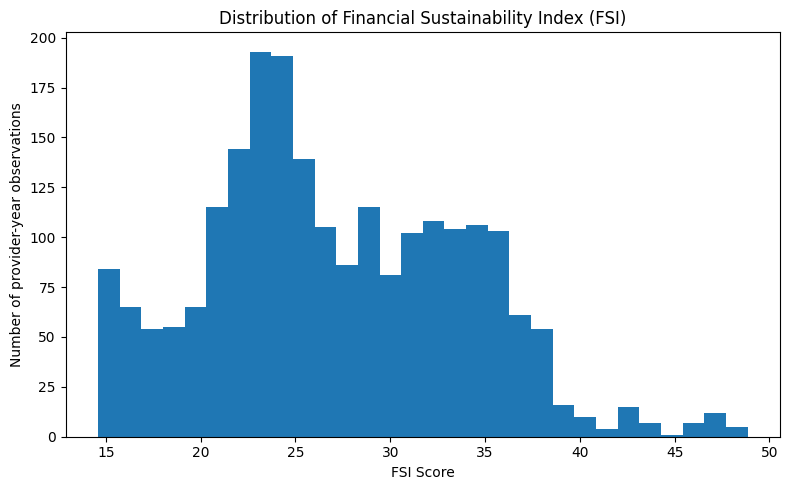

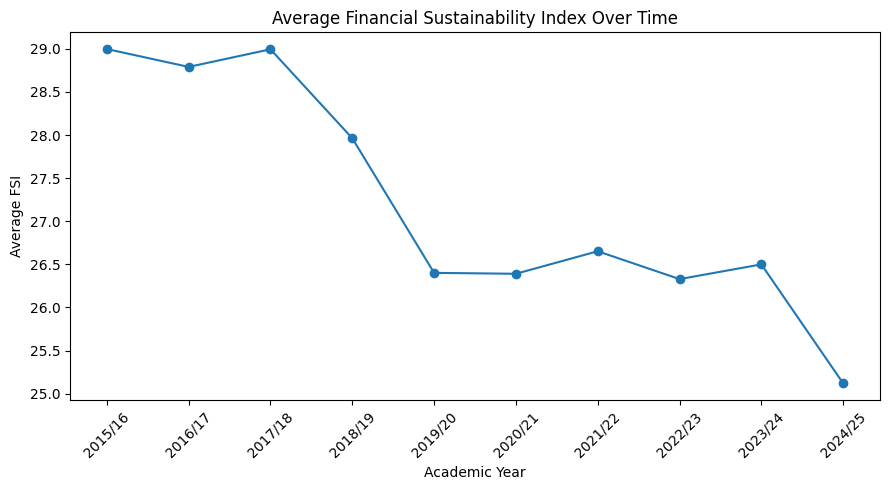

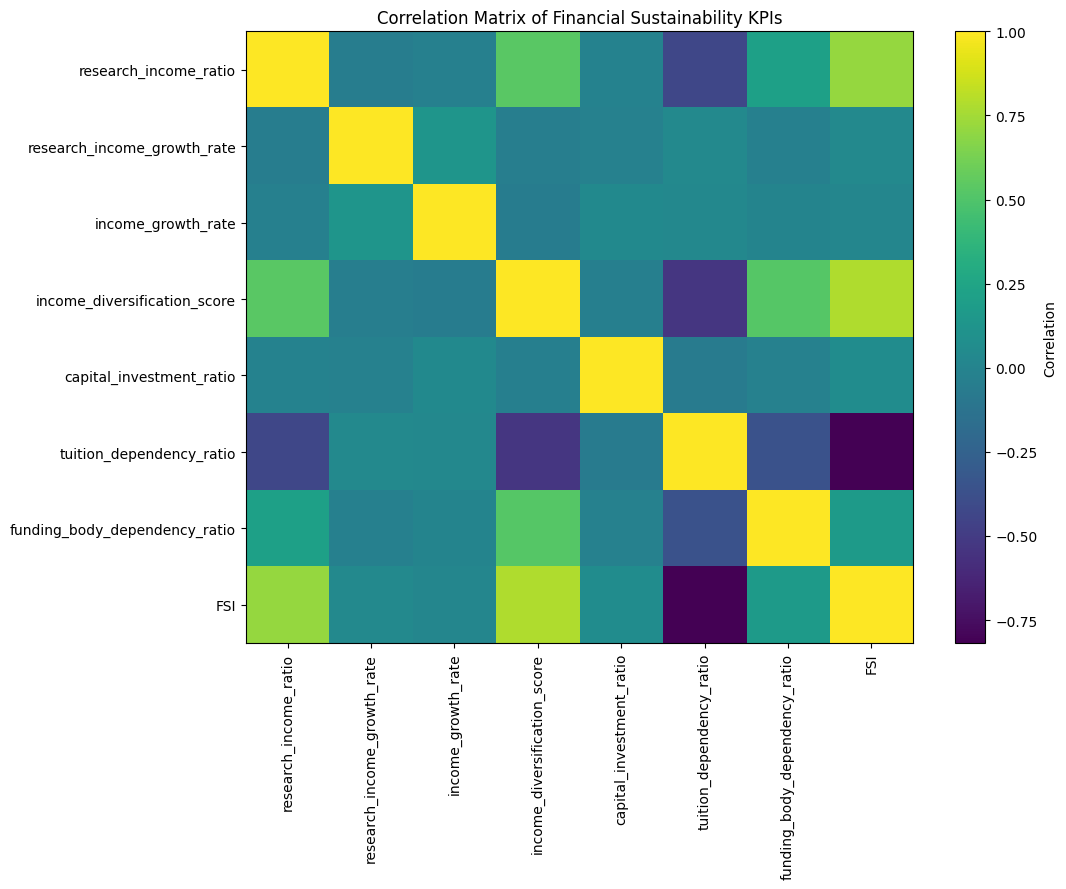

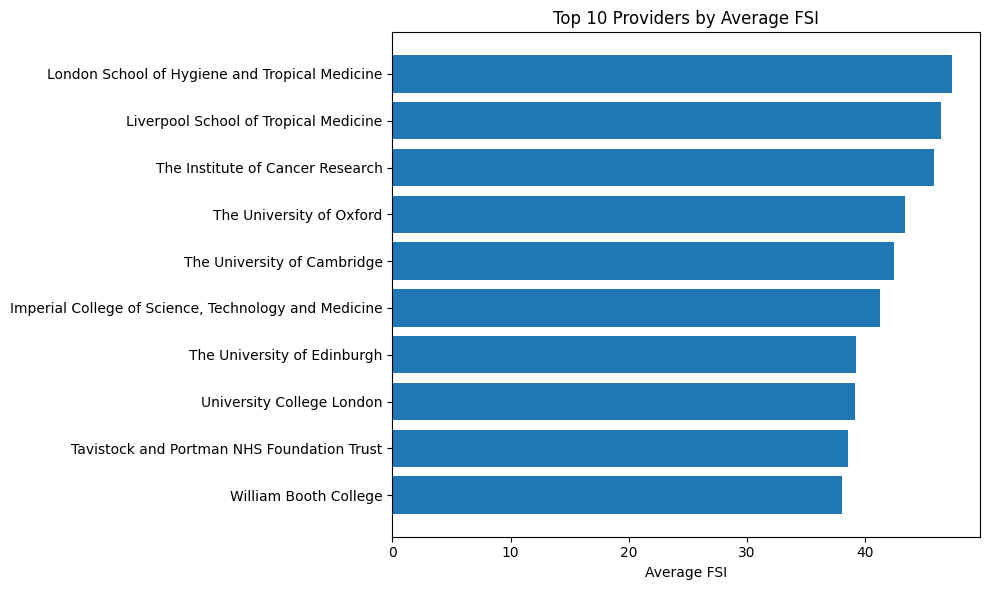

In [43]:
# ============================================================
# C. EXPLORATORY VISUALISATIONS
# ============================================================

import matplotlib.pyplot as plt

plot_dir = "/content/drive/MyDrive/HESA_outputs"
os.makedirs(plot_dir, exist_ok=True)

# 1. FSI distribution
plt.figure(figsize=(8, 5))
plt.hist(panel["FSI"].dropna(), bins=30)
plt.title("Distribution of Financial Sustainability Index (FSI)")
plt.xlabel("FSI Score")
plt.ylabel("Number of provider-year observations")
plt.tight_layout()
plt.savefig(f"{plot_dir}/01_fsi_distribution.png", dpi=300)
plt.show()

# 2. Average FSI over time
fsi_year = panel.groupby("academic_year", as_index=False)["FSI"].mean()

plt.figure(figsize=(9, 5))
plt.plot(fsi_year["academic_year"], fsi_year["FSI"], marker="o")
plt.title("Average Financial Sustainability Index Over Time")
plt.xlabel("Academic Year")
plt.ylabel("Average FSI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{plot_dir}/02_average_fsi_over_time.png", dpi=300)
plt.show()

# 3. KPI correlation heatmap
corr_cols = available_kpis + ["FSI"]
corr_df = panel[corr_cols].replace([np.inf, -np.inf], np.nan).corr()

plt.figure(figsize=(11, 9))
plt.imshow(corr_df, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.title("Correlation Matrix of Financial Sustainability KPIs")
plt.tight_layout()
plt.savefig(f"{plot_dir}/03_kpi_correlation_matrix.png", dpi=300)
plt.show()

# 4. Top 10 providers by average FSI
top_providers = (
    panel.groupby("provider", as_index=False)["FSI"]
    .mean()
    .sort_values("FSI", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(top_providers["provider"], top_providers["FSI"])
plt.title("Top 10 Providers by Average FSI")
plt.xlabel("Average FSI")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{plot_dir}/04_top10_providers_fsi.png", dpi=300)
plt.show()

In [44]:
# ============================================================
# D. PREDICTION MODEL: NEXT-YEAR FSI
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

panel = panel.sort_values(["UKPRN", "year_start"])

panel["FSI_next_year"] = panel.groupby("UKPRN")["FSI"].shift(-1)

model_features = available_kpis + ["FSI"]

model_df = panel[
    ["UKPRN", "provider", "academic_year", "year_start", "FSI_next_year"] + model_features
].replace([np.inf, -np.inf], np.nan)

model_df = model_df.dropna(subset=["FSI_next_year"])

for col in model_features:
    model_df[col] = model_df[col].fillna(model_df[col].median())

X = model_df[model_features]
y = model_df["FSI_next_year"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

reg_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Prediction Model Performance")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R2:", round(r2, 3))

Prediction Model Performance
MAE: 1.413
RMSE: 2.479
R2: 0.871


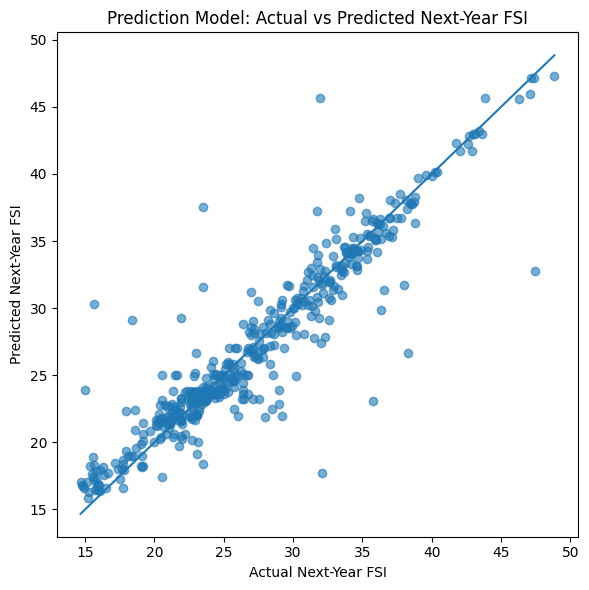

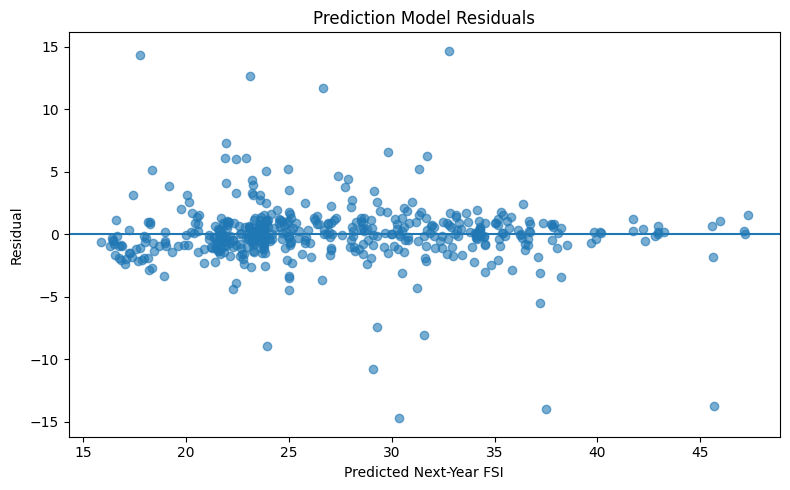

In [46]:
# Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Prediction Model: Actual vs Predicted Next-Year FSI")
plt.xlabel("Actual Next-Year FSI")
plt.ylabel("Predicted Next-Year FSI")
plt.tight_layout()
plt.savefig(f"{plot_dir}/05_prediction_actual_vs_predicted.png", dpi=300)
plt.show()

# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0)
plt.title("Prediction Model Residuals")
plt.xlabel("Predicted Next-Year FSI")
plt.ylabel("Residual")
plt.tight_layout()
plt.savefig(f"{plot_dir}/06_prediction_residuals.png", dpi=300)
plt.show()

In [47]:
# ============================================================
# E. RISK CLASSIFICATION
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Use quantiles because FSI scale is data-driven, not absolute.
q33 = panel["FSI"].quantile(0.33)
q66 = panel["FSI"].quantile(0.66)

def risk_level(fsi):
    if pd.isna(fsi):
        return np.nan
    elif fsi <= q33:
        return "High Risk"
    elif fsi <= q66:
        return "Medium Risk"
    else:
        return "Low Risk"

panel["risk_level"] = panel["FSI"].apply(risk_level)
panel["risk_next_year"] = panel.groupby("UKPRN")["risk_level"].shift(-1)

risk_df = panel[
    ["UKPRN", "provider", "academic_year", "risk_next_year"] + model_features
].replace([np.inf, -np.inf], np.nan)

risk_df = risk_df.dropna(subset=["risk_next_year"])

for col in model_features:
    risk_df[col] = risk_df[col].fillna(risk_df[col].median())

X = risk_df[model_features]
y = risk_df["risk_next_year"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

risk_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

risk_model.fit(X_train, y_train)
risk_pred = risk_model.predict(X_test)

print("Risk Classification Performance")
print("Accuracy:", round(accuracy_score(y_test, risk_pred), 3))
print(classification_report(y_test, risk_pred))

Risk Classification Performance
Accuracy: 0.853
              precision    recall  f1-score   support

   High Risk       0.89      0.81      0.84       155
    Low Risk       0.93      0.91      0.92       163
 Medium Risk       0.76      0.84      0.80       152

    accuracy                           0.85       470
   macro avg       0.86      0.85      0.85       470
weighted avg       0.86      0.85      0.85       470



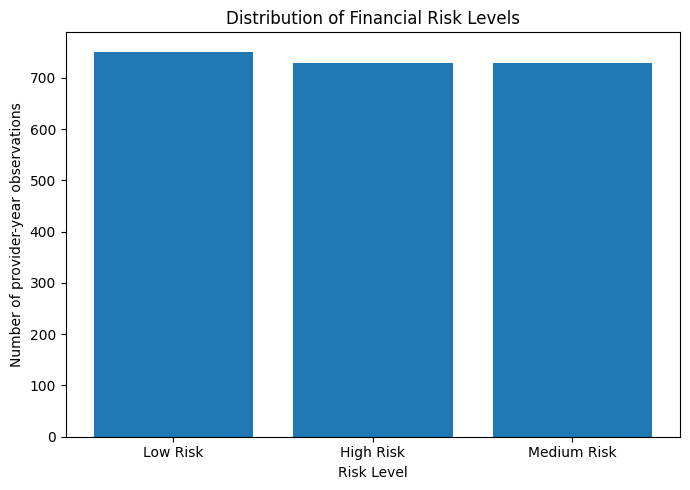

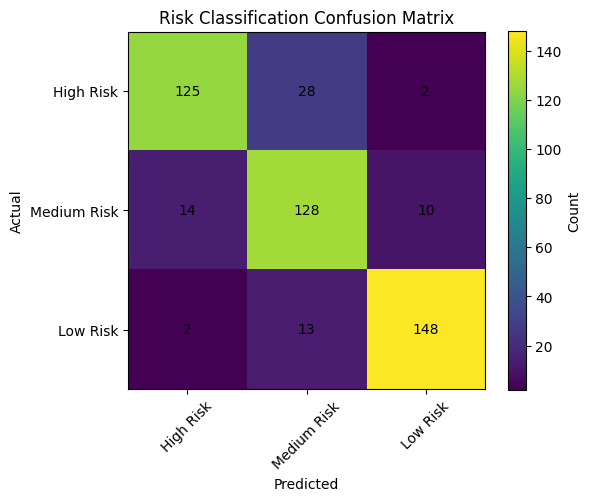

In [48]:
# Risk distribution
risk_counts = panel["risk_level"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(risk_counts.index, risk_counts.values)
plt.title("Distribution of Financial Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of provider-year observations")
plt.tight_layout()
plt.savefig(f"{plot_dir}/07_risk_distribution.png", dpi=300)
plt.show()

# Confusion matrix
labels = ["High Risk", "Medium Risk", "Low Risk"]
cm = confusion_matrix(y_test, risk_pred, labels=labels)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Risk Classification Confusion Matrix")
plt.colorbar(label="Count")
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(f"{plot_dir}/08_risk_confusion_matrix.png", dpi=300)
plt.show()

In [58]:
# ============================================================
# F. CLUSTERING MODEL - FIXED VERSION
# ============================================================

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Remove old cluster columns if they exist
old_cluster_cols = [c for c in panel.columns if c.startswith("cluster")]
if old_cluster_cols:
    panel = panel.drop(columns=old_cluster_cols)

cluster_features = available_kpis + ["FSI"]

cluster_df = panel[
    ["UKPRN", "provider", "academic_year"] + cluster_features
].copy()

cluster_df = cluster_df.replace([np.inf, -np.inf], np.nan)

for col in cluster_features:
    cluster_df[col] = cluster_df[col].fillna(cluster_df[col].median())

scaler = MinMaxScaler()
X_cluster = scaler.fit_transform(cluster_df[cluster_features])

# Test silhouette for k = 2 to 8
silhouette_results = {}

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_cluster)
    silhouette_results[k] = silhouette_score(X_cluster, labels_k)

print("Silhouette scores:")
for k, score in silhouette_results.items():
    print(k, round(score, 3))

best_k = max(silhouette_results, key=silhouette_results.get)
print("Best k:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

cluster_df["cluster"] = cluster_labels

# Add cluster directly to panel by row order
panel["cluster"] = cluster_labels

print("Cluster column exists:", "cluster" in panel.columns)
print(panel["cluster"].value_counts().sort_index())

cluster_summary = panel.groupby("cluster")[cluster_features].mean().round(3)
cluster_summary

Silhouette scores:
2 0.463
3 0.492
4 0.422
5 0.449
6 0.448
7 0.411
8 0.426
Best k: 3
Cluster column exists: True
cluster
0     935
1    1128
2     144
Name: count, dtype: int64


,research_income_ratio,research_income_growth_rate,income_growth_rate,income_diversification_score,capital_investment_ratio,tuition_dependency_ratio,funding_body_dependency_ratio,FSI
cluster,,,,,,,,
0,0.116,inf,0.239,0.633,0.400,0.438,0.191,32.554
1,0.012,inf,inf,0.308,0.385,0.812,0.066,21.871
2,0.012,inf,inf,0.245,6.146,0.063,0.007,32.678


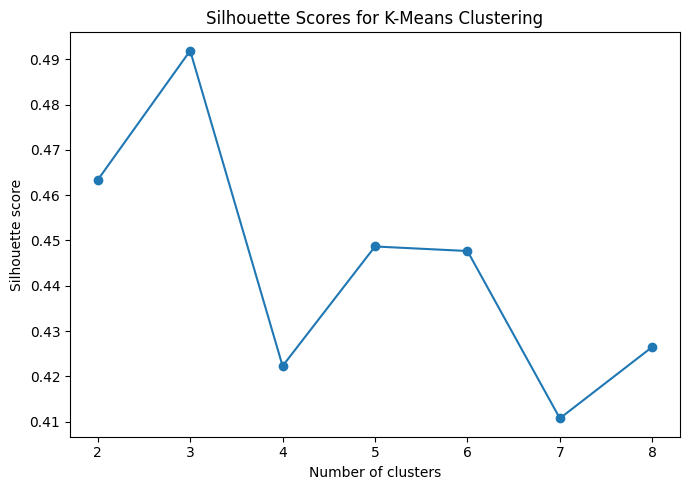

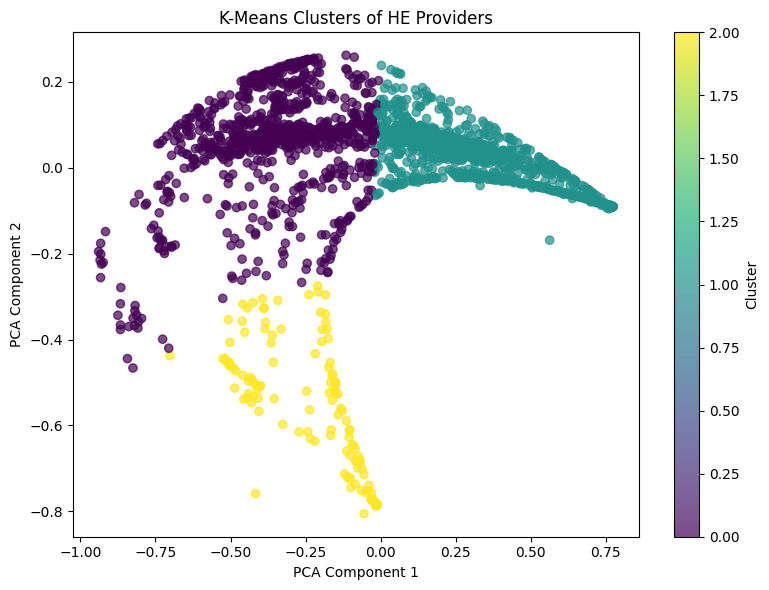

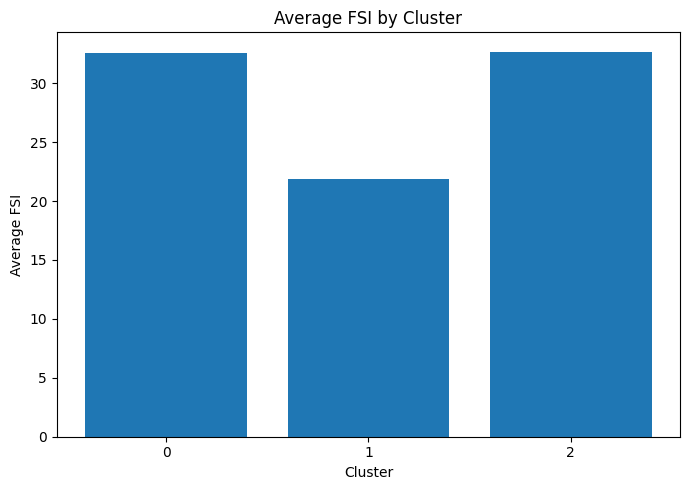

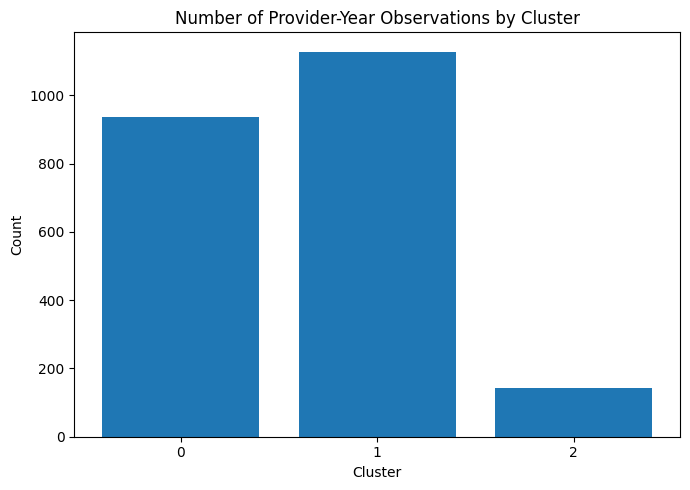

In [61]:
# ============================================================
# CLUSTERING PLOTS - FIXED VERSION
# ============================================================

import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

plot_dir = "/content/drive/MyDrive/HESA_outputs"
os.makedirs(plot_dir, exist_ok=True)

# 1. Silhouette score plot
plt.figure(figsize=(7, 5))
plt.plot(list(silhouette_results.keys()), list(silhouette_results.values()), marker="o")
plt.title("Silhouette Scores for K-Means Clustering")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.savefig(f"{plot_dir}/09_clustering_silhouette_scores.png", dpi=300)
plt.show()

# 2. PCA cluster visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=panel["cluster"], alpha=0.7)
plt.title("K-Means Clusters of HE Providers")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.savefig(f"{plot_dir}/10_cluster_pca_visualisation.png", dpi=300)
plt.show()

# 3. Average FSI by cluster
cluster_fsi = panel.groupby("cluster", as_index=False)["FSI"].mean()

plt.figure(figsize=(7, 5))
plt.bar(cluster_fsi["cluster"].astype(str), cluster_fsi["FSI"])
plt.title("Average FSI by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average FSI")
plt.tight_layout()
plt.savefig(f"{plot_dir}/11_average_fsi_by_cluster.png", dpi=300)
plt.show()

# 4. Cluster size
cluster_counts = panel["cluster"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("Number of Provider-Year Observations by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{plot_dir}/11b_cluster_size.png", dpi=300)
plt.show()

In [62]:
print(panel["cluster"].value_counts().sort_index())
print(cluster_summary)

cluster
0     935
1    1128
2     144
Name: count, dtype: int64
         research_income_ratio  research_income_growth_rate  \
cluster                                                       
0                        0.116                          inf   
1                        0.012                          inf   
2                        0.012                          inf   

         income_growth_rate  income_diversification_score  \
cluster                                                     
0                     0.239                         0.633   
1                       inf                         0.308   
2                       inf                         0.245   

         capital_investment_ratio  tuition_dependency_ratio  \
cluster                                                       
0                           0.400                     0.438   
1                           0.385                     0.812   
2                           6.146                     0.063   

In [63]:
# ============================================================
# G. ANOMALY DETECTION - FIXED VERSION
# ============================================================

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

plot_dir = "/content/drive/MyDrive/HESA_outputs"
os.makedirs(plot_dir, exist_ok=True)

# Remove old anomaly columns if they exist
old_anomaly_cols = [
    c for c in panel.columns
    if c.startswith("anomaly") or c in ["anomaly_score", "anomaly_flag"]
]

if old_anomaly_cols:
    panel = panel.drop(columns=old_anomaly_cols)

# Use same features as clustering / FSI
anomaly_features = available_kpis + ["FSI"]

anomaly_df = panel[
    ["UKPRN", "provider", "academic_year"] + anomaly_features
].copy()

anomaly_df = anomaly_df.replace([np.inf, -np.inf], np.nan)

for col in anomaly_features:
    anomaly_df[col] = anomaly_df[col].fillna(anomaly_df[col].median())

scaler = MinMaxScaler()
X_anomaly = scaler.fit_transform(anomaly_df[anomaly_features])

anomaly_model = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

anomaly_raw = anomaly_model.fit_predict(X_anomaly)
anomaly_score = anomaly_model.decision_function(X_anomaly)

# Add directly to panel by row order
panel["anomaly_raw"] = anomaly_raw
panel["anomaly_score"] = anomaly_score
panel["anomaly_flag"] = np.where(anomaly_raw == -1, "Anomaly", "Normal")

print("Anomaly columns added:")
print([c for c in panel.columns if "anomaly" in c])

print("\nAnomaly counts:")
print(panel["anomaly_flag"].value_counts())

anomaly_cases = (
    panel[panel["anomaly_flag"] == "Anomaly"]
    .sort_values("anomaly_score")
)

anomaly_cases[
    ["provider", "academic_year", "FSI", "risk_level", "anomaly_score"]
].head(20)

Anomaly columns added:
['anomaly_raw', 'anomaly_score', 'anomaly_flag']

Anomaly counts:
anomaly_flag
Normal     2096
Anomaly     111
Name: count, dtype: int64


,provider,academic_year,FSI,risk_level,anomaly_score
2172,The Engineering and Design Institute London,2020/21,47.458920,Low Risk,-0.199361
2173,The Engineering and Design Institute London,2021/22,31.920096,Low Risk,-0.160654
1048,London School of Hygiene and Tropical Medicine,2017/18,48.293178,Low Risk,-0.147487
1443,Royal Academy of Music,2017/18,38.025834,Low Risk,-0.136257
339,Liverpool School of Tropical Medicine,2017/18,44.304906,Low Risk,-0.131452
236,The Institute of Cancer Research,2017/18,46.326233,Low Risk,-0.127002
2171,The Engineering and Design Institute London,2019/20,31.997062,Low Risk,-0.120598
338,Liverpool School of Tropical Medicine,2016/17,48.844074,Low Risk,-0.120407
681,University of the Highlands and Islands,2017/18,26.608703,Medium Risk,-0.115078
2119,The London Interdisciplinary School Ltd,2021/22,29.222933,Medium Risk,-0.115026


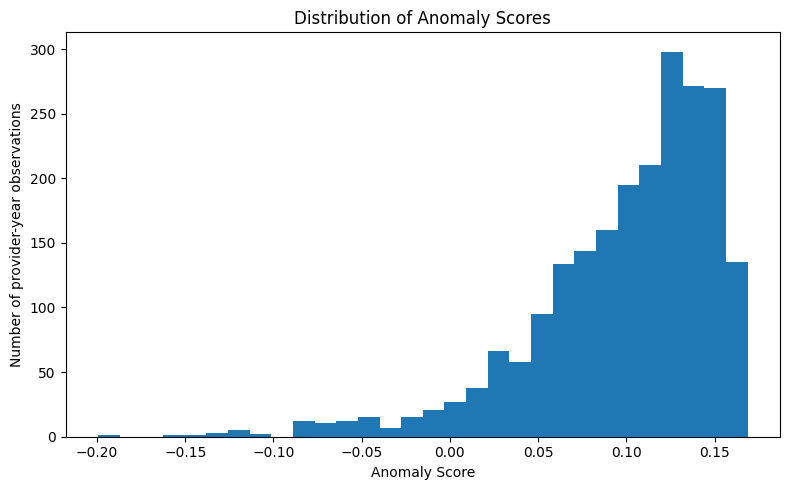

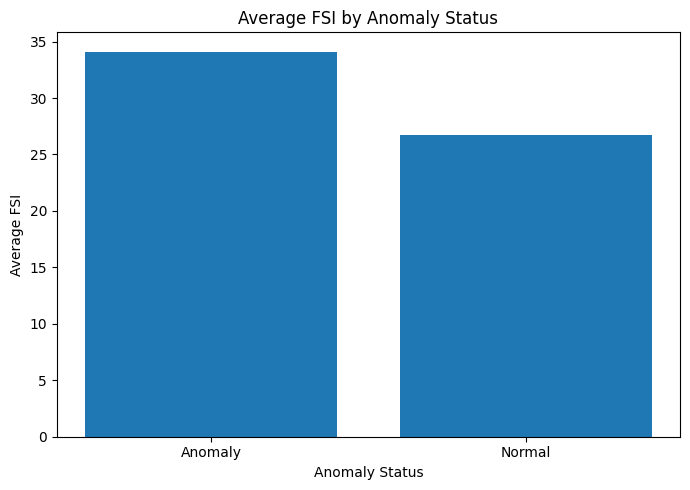

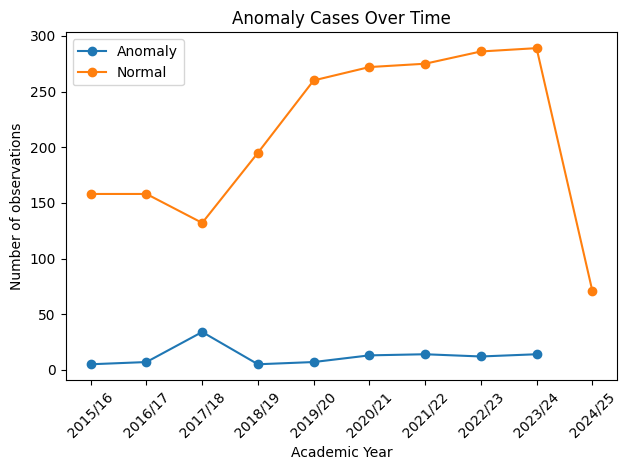

In [64]:
# ============================================================
# ANOMALY DETECTION PLOTS - FIXED VERSION
# ============================================================

# 1. Anomaly score distribution
plt.figure(figsize=(8, 5))
plt.hist(panel["anomaly_score"].dropna(), bins=30)
plt.title("Distribution of Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of provider-year observations")
plt.tight_layout()
plt.savefig(f"{plot_dir}/12_anomaly_score_distribution.png", dpi=300)
plt.show()

# 2. Average FSI by anomaly flag
anomaly_fsi = panel.groupby("anomaly_flag", as_index=False)["FSI"].mean()

plt.figure(figsize=(7, 5))
plt.bar(anomaly_fsi["anomaly_flag"], anomaly_fsi["FSI"])
plt.title("Average FSI by Anomaly Status")
plt.xlabel("Anomaly Status")
plt.ylabel("Average FSI")
plt.tight_layout()
plt.savefig(f"{plot_dir}/13_average_fsi_by_anomaly_status.png", dpi=300)
plt.show()

# 3. Anomaly cases over time
anomaly_year = (
    panel.groupby(["academic_year", "anomaly_flag"])
    .size()
    .reset_index(name="count")
)

for flag in anomaly_year["anomaly_flag"].unique():
    subset = anomaly_year[anomaly_year["anomaly_flag"] == flag]
    plt.plot(subset["academic_year"], subset["count"], marker="o", label=flag)

plt.title("Anomaly Cases Over Time")
plt.xlabel("Academic Year")
plt.ylabel("Number of observations")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(f"{plot_dir}/13b_anomaly_cases_over_time.png", dpi=300)
plt.show()

In [66]:
print(panel["anomaly_flag"].value_counts())
print(anomaly_cases[["provider", "academic_year", "FSI", "risk_level", "anomaly_score"]].head(10))

anomaly_flag
Normal     2096
Anomaly     111
Name: count, dtype: int64
                                            provider academic_year        FSI  \
2172     The Engineering and Design Institute London       2020/21  47.458920   
2173     The Engineering and Design Institute London       2021/22  31.920096   
1048  London School of Hygiene and Tropical Medicine       2017/18  48.293178   
1443                          Royal Academy of Music       2017/18  38.025834   
339            Liverpool School of Tropical Medicine       2017/18  44.304906   
236                 The Institute of Cancer Research       2017/18  46.326233   
2171     The Engineering and Design Institute London       2019/20  31.997062   
338            Liverpool School of Tropical Medicine       2016/17  48.844074   
681          University of the Highlands and Islands       2017/18  26.608703   
2119         The London Interdisciplinary School Ltd       2021/22  29.222933   

       risk_level  anomaly_score  
21

Random Forest Feature Importance:
                         feature  importance
7                            FSI    0.916201
5       tuition_dependency_ratio    0.028775
3   income_diversification_score    0.015258
4       capital_investment_ratio    0.014780
2             income_growth_rate    0.014741
6  funding_body_dependency_ratio    0.004473
0          research_income_ratio    0.003643
1    research_income_growth_rate    0.002128

Permutation Importance:
                         feature  permutation_importance
7                            FSI                1.528773
5       tuition_dependency_ratio                0.018012
3   income_diversification_score                0.008339
4       capital_investment_ratio                0.004718
1    research_income_growth_rate                0.000586
2             income_growth_rate                0.000201
6  funding_body_dependency_ratio               -0.000592
0          research_income_ratio               -0.000836


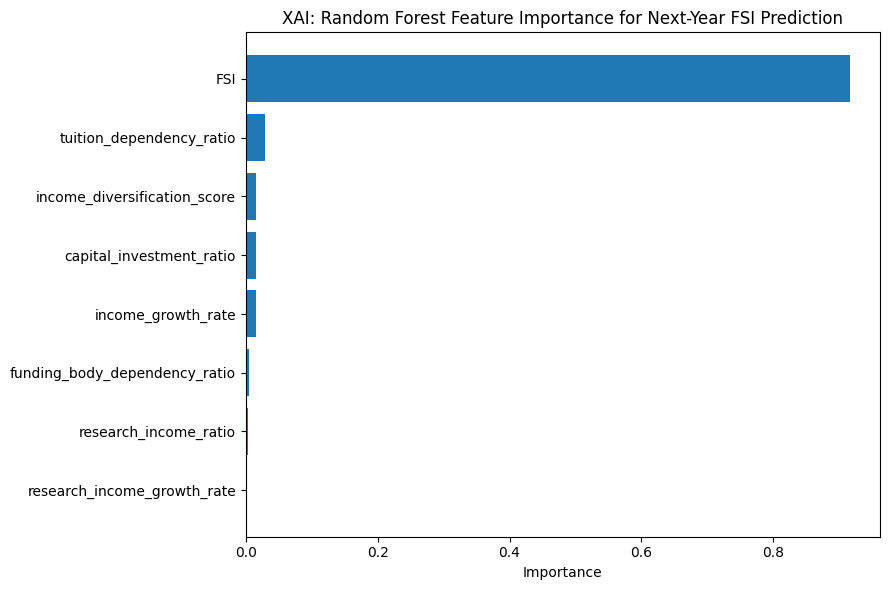

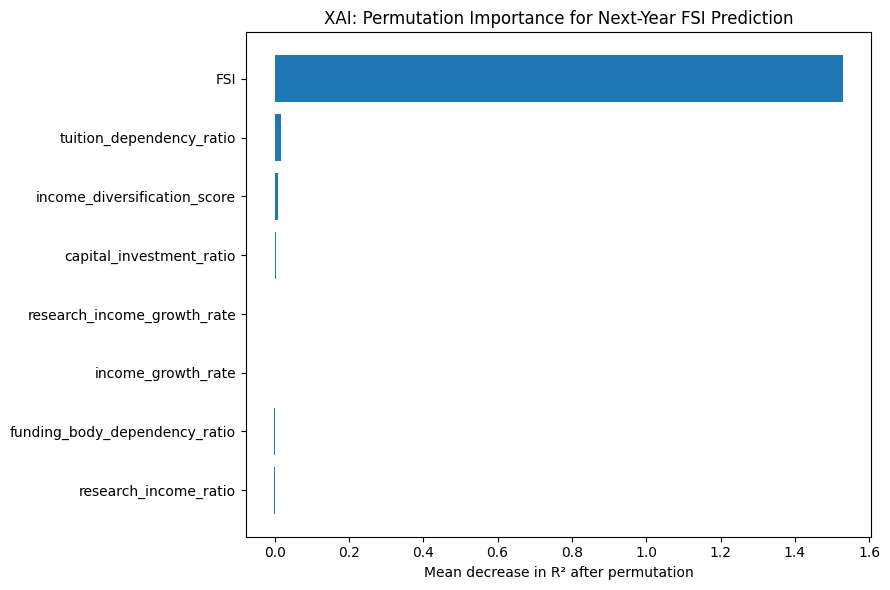

In [67]:
# ============================================================
# H. XAI: FEATURE IMPORTANCE + PERMUTATION IMPORTANCE - FIXED
# ============================================================

from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import os

plot_dir = "/content/drive/MyDrive/HESA_outputs"
os.makedirs(plot_dir, exist_ok=True)

# Rebuild regression test data to avoid conflict with risk classification X_test/y_test
X_reg = model_df[model_features].copy()
y_reg = model_df["FSI_next_year"].copy()

for col in model_features:
    X_reg[col] = X_reg[col].fillna(X_reg[col].median())

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=42
)

# Use existing reg_model if already trained; otherwise retrain safely
reg_model.fit(X_train_reg, y_train_reg)

# 1. Random Forest built-in feature importance
feature_importance = pd.DataFrame({
    "feature": model_features,
    "importance": reg_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Random Forest Feature Importance:")
print(feature_importance)

# 2. Permutation importance for regression model
perm = permutation_importance(
    reg_model,
    X_test_reg,
    y_test_reg,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

permutation_importance_df = pd.DataFrame({
    "feature": model_features,
    "permutation_importance": perm.importances_mean
}).sort_values("permutation_importance", ascending=False)

print("\nPermutation Importance:")
print(permutation_importance_df)

# 3. Feature importance plot
top_fi = feature_importance.head(12)

plt.figure(figsize=(9, 6))
plt.barh(top_fi["feature"], top_fi["importance"])
plt.title("XAI: Random Forest Feature Importance for Next-Year FSI Prediction")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{plot_dir}/14_xai_feature_importance.png", dpi=300)
plt.show()

# 4. Permutation importance plot
top_perm = permutation_importance_df.head(12)

plt.figure(figsize=(9, 6))
plt.barh(top_perm["feature"], top_perm["permutation_importance"])
plt.title("XAI: Permutation Importance for Next-Year FSI Prediction")
plt.xlabel("Mean decrease in R² after permutation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{plot_dir}/15_xai_permutation_importance.png", dpi=300)
plt.show()

Prediction without current FSI
MAE: 1.358
RMSE: 2.352
R2: 0.884

Feature Importance without FSI:
                         feature  importance
5       tuition_dependency_ratio    0.668247
0          research_income_ratio    0.152240
3   income_diversification_score    0.092646
6  funding_body_dependency_ratio    0.055163
4       capital_investment_ratio    0.016176
2             income_growth_rate    0.012902
1    research_income_growth_rate    0.002626


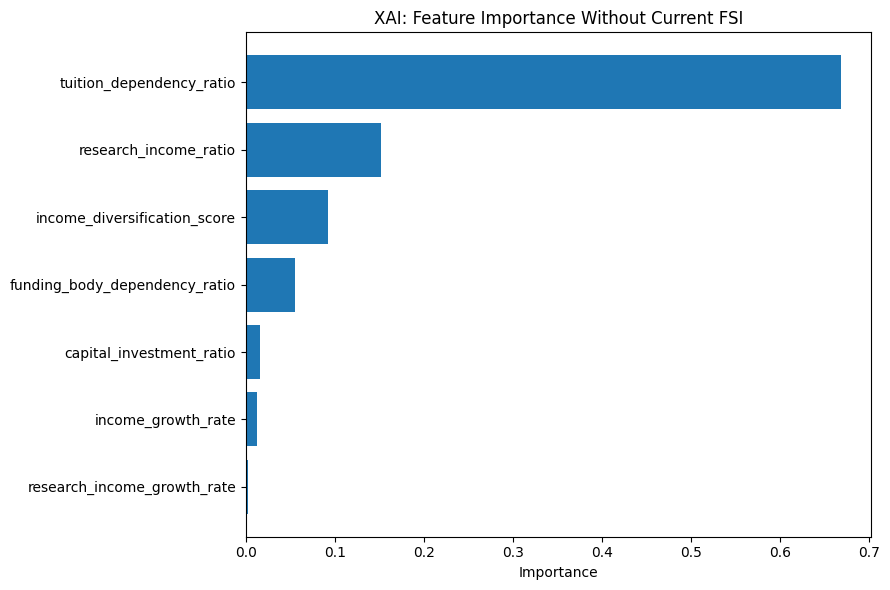

In [68]:
# ============================================================
# H2. XAI WITHOUT CURRENT FSI
# ============================================================

model_features_no_fsi = [f for f in model_features if f != "FSI"]

X_reg2 = model_df[model_features_no_fsi].copy()
y_reg2 = model_df["FSI_next_year"].copy()

for col in model_features_no_fsi:
    X_reg2[col] = X_reg2[col].fillna(X_reg2[col].median())

X_train_reg2, X_test_reg2, y_train_reg2, y_test_reg2 = train_test_split(
    X_reg2,
    y_reg2,
    test_size=0.25,
    random_state=42
)

reg_model_no_fsi = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

reg_model_no_fsi.fit(X_train_reg2, y_train_reg2)

y_pred_reg2 = reg_model_no_fsi.predict(X_test_reg2)

print("Prediction without current FSI")
print("MAE:", round(mean_absolute_error(y_test_reg2, y_pred_reg2), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_reg2, y_pred_reg2)), 3))
print("R2:", round(r2_score(y_test_reg2, y_pred_reg2), 3))

feature_importance_no_fsi = pd.DataFrame({
    "feature": model_features_no_fsi,
    "importance": reg_model_no_fsi.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeature Importance without FSI:")
print(feature_importance_no_fsi)

plt.figure(figsize=(9, 6))
plt.barh(feature_importance_no_fsi["feature"], feature_importance_no_fsi["importance"])
plt.title("XAI: Feature Importance Without Current FSI")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{plot_dir}/16_xai_feature_importance_without_fsi.png", dpi=300)
plt.show()

Prediction without current FSI
MAE: 1.358
RMSE: 2.352
R2: 0.884

Feature Importance without FSI:
                         feature  importance
5       tuition_dependency_ratio    0.668247
0          research_income_ratio    0.152240
3   income_diversification_score    0.092646
6  funding_body_dependency_ratio    0.055163
4       capital_investment_ratio    0.016176
2             income_growth_rate    0.012902
1    research_income_growth_rate    0.002626

Permutation Importance without FSI:
                         feature  permutation_importance
5       tuition_dependency_ratio                0.850469
0          research_income_ratio                0.155876
3   income_diversification_score                0.139317
6  funding_body_dependency_ratio                0.098022
4       capital_investment_ratio                0.004525
2             income_growth_rate                0.000650
1    research_income_growth_rate                0.000090


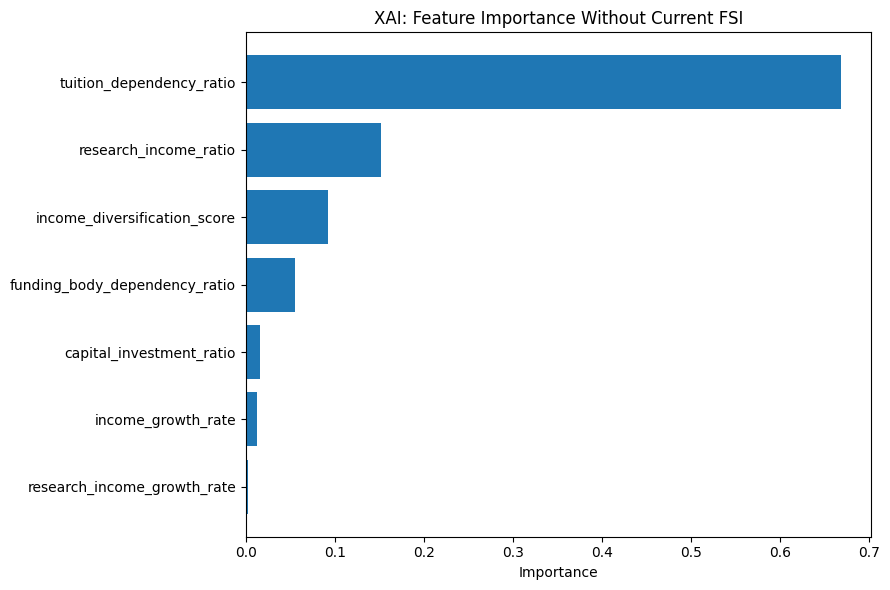

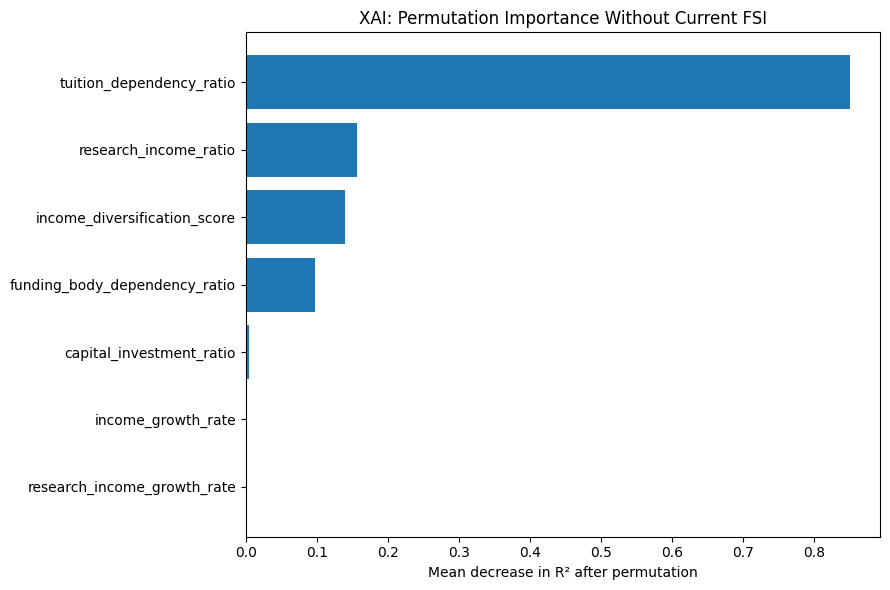

In [69]:
# ============================================================
# H2. XAI WITHOUT CURRENT FSI - COMPLETE FIXED VERSION
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

plot_dir = "/content/drive/MyDrive/HESA_outputs"
os.makedirs(plot_dir, exist_ok=True)

# Features without current FSI
model_features_no_fsi = [f for f in model_features if f != "FSI"]

X_reg2 = model_df[model_features_no_fsi].copy()
y_reg2 = model_df["FSI_next_year"].copy()

X_reg2 = X_reg2.replace([np.inf, -np.inf], np.nan)

for col in model_features_no_fsi:
    X_reg2[col] = X_reg2[col].fillna(X_reg2[col].median())

X_train_reg2, X_test_reg2, y_train_reg2, y_test_reg2 = train_test_split(
    X_reg2,
    y_reg2,
    test_size=0.25,
    random_state=42
)

reg_model_no_fsi = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

reg_model_no_fsi.fit(X_train_reg2, y_train_reg2)

y_pred_reg2 = reg_model_no_fsi.predict(X_test_reg2)

mae_no_fsi = mean_absolute_error(y_test_reg2, y_pred_reg2)
rmse_no_fsi = np.sqrt(mean_squared_error(y_test_reg2, y_pred_reg2))
r2_no_fsi = r2_score(y_test_reg2, y_pred_reg2)

print("Prediction without current FSI")
print("MAE:", round(mae_no_fsi, 3))
print("RMSE:", round(rmse_no_fsi, 3))
print("R2:", round(r2_no_fsi, 3))

# Built-in feature importance
feature_importance_no_fsi = pd.DataFrame({
    "feature": model_features_no_fsi,
    "importance": reg_model_no_fsi.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeature Importance without FSI:")
print(feature_importance_no_fsi)

# Permutation importance
perm_no_fsi = permutation_importance(
    reg_model_no_fsi,
    X_test_reg2,
    y_test_reg2,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

permutation_importance_no_fsi_df = pd.DataFrame({
    "feature": model_features_no_fsi,
    "permutation_importance": perm_no_fsi.importances_mean
}).sort_values("permutation_importance", ascending=False)

print("\nPermutation Importance without FSI:")
print(permutation_importance_no_fsi_df)

# Plot 1: Feature importance without FSI
top_fi_no_fsi = feature_importance_no_fsi.head(12)

plt.figure(figsize=(9, 6))
plt.barh(top_fi_no_fsi["feature"], top_fi_no_fsi["importance"])
plt.title("XAI: Feature Importance Without Current FSI")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{plot_dir}/16_xai_feature_importance_without_fsi.png", dpi=300)
plt.show()

# Plot 2: Permutation importance without FSI
top_perm_no_fsi = permutation_importance_no_fsi_df.head(12)

plt.figure(figsize=(9, 6))
plt.barh(top_perm_no_fsi["feature"], top_perm_no_fsi["permutation_importance"])
plt.title("XAI: Permutation Importance Without Current FSI")
plt.xlabel("Mean decrease in R² after permutation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{plot_dir}/17_xai_permutation_importance_without_fsi.png", dpi=300)
plt.show()

# **Export Result**

In [70]:
# ============================================================
# I. EXPORT ALL OUTPUTS TO GOOGLE DRIVE
# ============================================================

import os
import pandas as pd
import joblib

# 1. Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

# 2. Create output folder
output_dir = "/content/drive/MyDrive/HESA_outputs"
os.makedirs(output_dir, exist_ok=True)

print("Saving outputs to:", output_dir)

# 3. Save final panel and main result files
panel.to_csv(f"{output_dir}/hesa_financial_sustainability_final_panel.csv", index=False)

# Save FSI-only dataset
fsi_export_cols = [
    c for c in [
        "UKPRN", "provider", "country", "region", "academic_year",
        "year_start", "total_income", "FSI", "risk_level",
        "cluster", "anomaly_score", "anomaly_flag"
    ]
    if c in panel.columns
]

panel[fsi_export_cols].to_csv(
    f"{output_dir}/hesa_fsi_risk_cluster_anomaly_summary.csv",
    index=False
)

# 4. Save model datasets
if "model_df" in globals():
    model_df.to_csv(f"{output_dir}/prediction_model_dataset.csv", index=False)

if "risk_df" in globals():
    risk_df.to_csv(f"{output_dir}/risk_classification_dataset.csv", index=False)

# 5. Save prediction results if available
if all(v in globals() for v in ["y_test_reg", "y_pred"]):
    prediction_results = pd.DataFrame({
        "actual_next_year_FSI": y_test_reg,
        "predicted_next_year_FSI": y_pred
    })
    prediction_results.to_csv(f"{output_dir}/prediction_actual_vs_predicted.csv", index=False)

elif all(v in globals() for v in ["y_test", "y_pred"]):
    prediction_results = pd.DataFrame({
        "actual_next_year_FSI": y_test,
        "predicted_next_year_FSI": y_pred
    })
    prediction_results.to_csv(f"{output_dir}/prediction_actual_vs_predicted.csv", index=False)

# 6. Save risk prediction results if available
if all(v in globals() for v in ["risk_pred", "y_test"]):
    risk_results = pd.DataFrame({
        "actual_risk_level": y_test,
        "predicted_risk_level": risk_pred
    })
    risk_results.to_csv(f"{output_dir}/risk_actual_vs_predicted.csv", index=False)

# 7. Save cluster summary
if "cluster_summary" in globals():
    cluster_summary.to_csv(f"{output_dir}/cluster_summary.csv")

# 8. Save anomaly cases
if "anomaly_cases" in globals():
    anomaly_cases.to_csv(f"{output_dir}/anomaly_cases.csv", index=False)

# 9. Save XAI outputs
if "feature_importance" in globals():
    feature_importance.to_csv(f"{output_dir}/xai_feature_importance_with_fsi.csv", index=False)

if "permutation_importance_df" in globals():
    permutation_importance_df.to_csv(f"{output_dir}/xai_permutation_importance_with_fsi.csv", index=False)

if "feature_importance_no_fsi" in globals():
    feature_importance_no_fsi.to_csv(f"{output_dir}/xai_feature_importance_without_fsi.csv", index=False)

if "permutation_importance_no_fsi_df" in globals():
    permutation_importance_no_fsi_df.to_csv(f"{output_dir}/xai_permutation_importance_without_fsi.csv", index=False)

# 10. Save trained models
if "reg_model" in globals():
    joblib.dump(reg_model, f"{output_dir}/random_forest_fsi_prediction_model.pkl")

if "reg_model_no_fsi" in globals():
    joblib.dump(reg_model_no_fsi, f"{output_dir}/random_forest_fsi_prediction_model_without_fsi.pkl")

if "risk_model" in globals():
    joblib.dump(risk_model, f"{output_dir}/random_forest_risk_classification_model.pkl")

if "kmeans" in globals():
    joblib.dump(kmeans, f"{output_dir}/kmeans_clustering_model.pkl")

if "anomaly_model" in globals():
    joblib.dump(anomaly_model, f"{output_dir}/isolation_forest_anomaly_model.pkl")

# 11. Save model performance summary
performance_rows = []

if all(v in globals() for v in ["mae", "rmse", "r2"]):
    performance_rows.append({
        "model": "Random Forest Regression - with current FSI",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

if all(v in globals() for v in ["mae_no_fsi", "rmse_no_fsi", "r2_no_fsi"]):
    performance_rows.append({
        "model": "Random Forest Regression - without current FSI",
        "MAE": mae_no_fsi,
        "RMSE": rmse_no_fsi,
        "R2": r2_no_fsi
    })

if "best_k" in globals():
    performance_rows.append({
        "model": "K-Means Clustering",
        "MAE": None,
        "RMSE": None,
        "R2": None,
        "best_k": best_k
    })

performance_summary = pd.DataFrame(performance_rows)
performance_summary.to_csv(f"{output_dir}/model_performance_summary.csv", index=False)

# 12. List saved files
print("\nSaved files:")
for file in sorted(os.listdir(output_dir)):
    print("-", file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving outputs to: /content/drive/MyDrive/HESA_outputs

Saved files:
- 01_fsi_distribution.png
- 02_average_fsi_over_time.png
- 03_kpi_correlation_matrix.png
- 04_top10_providers_fsi.png
- 05_prediction_actual_vs_predicted.png
- 06_prediction_residuals.png
- 07_risk_distribution.png
- 08_risk_confusion_matrix.png
- 09_clustering_silhouette_scores.png
- 10_cluster_pca_visualisation.png
- 11_average_fsi_by_cluster.png
- 11b_cluster_size.png
- 12_anomaly_score_distribution.png
- 13_average_fsi_by_anomaly_status.png
- 13b_anomaly_cases_over_time.png
- 14_xai_feature_importance.png
- 15_xai_permutation_importance.png
- 16_xai_feature_importance_without_fsi.png
- 17_xai_permutation_importance_without_fsi.png
- anomaly_cases.csv
- cluster_summary.csv
- hesa_financial_sustainability_final_panel.csv
- hesa_fsi_risk_cluster_anomaly_summary.csv
- isolation_forest_anomal